In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
print("Environment working")

Environment working


In [4]:
df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")



In [5]:
import os

os.listdir("dataset/cicids2017")


['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']

In [6]:
import pandas as pd

# Load the CSV
df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Quick look at the first 5 rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
# Number of rows and columns
print("Shape:", df.shape)

# Column names and types
df.info()

Shape: (225745, 79)
<class 'pandas.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       22574

In [8]:
# Remove any duplicate header rows
df = df[df['Label'] != 'Label']

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

# Check shape and first 5 rows again
print(df.shape)
df.head()

KeyError: 'Label'

In [9]:
# Show all column names
df.columns.tolist()

[' Destination Port',
 ' Flow Duration',
 ' Total Fwd Packets',
 ' Total Backward Packets',
 'Total Length of Fwd Packets',
 ' Total Length of Bwd Packets',
 ' Fwd Packet Length Max',
 ' Fwd Packet Length Min',
 ' Fwd Packet Length Mean',
 ' Fwd Packet Length Std',
 'Bwd Packet Length Max',
 ' Bwd Packet Length Min',
 ' Bwd Packet Length Mean',
 ' Bwd Packet Length Std',
 'Flow Bytes/s',
 ' Flow Packets/s',
 ' Flow IAT Mean',
 ' Flow IAT Std',
 ' Flow IAT Max',
 ' Flow IAT Min',
 'Fwd IAT Total',
 ' Fwd IAT Mean',
 ' Fwd IAT Std',
 ' Fwd IAT Max',
 ' Fwd IAT Min',
 'Bwd IAT Total',
 ' Bwd IAT Mean',
 ' Bwd IAT Std',
 ' Bwd IAT Max',
 ' Bwd IAT Min',
 'Fwd PSH Flags',
 ' Bwd PSH Flags',
 ' Fwd URG Flags',
 ' Bwd URG Flags',
 ' Fwd Header Length',
 ' Bwd Header Length',
 'Fwd Packets/s',
 ' Bwd Packets/s',
 ' Min Packet Length',
 ' Max Packet Length',
 ' Packet Length Mean',
 ' Packet Length Std',
 ' Packet Length Variance',
 'FIN Flag Count',
 ' SYN Flag Count',
 ' RST Flag Count',
 ' P

In [10]:
# Remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()

# Check the column names again
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [11]:
# Remove any duplicate header rows if they exist
df = df[df['Label'] != 'Label']

# Reset index
df.reset_index(drop=True, inplace=True)

# See the first few rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [12]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Remove any duplicate header rows that accidentally appear in the data
df = df[df['Label'] != 'Label']

# Reset index
df.reset_index(drop=True, inplace=True)

# Quick check
print(df['Label'].value_counts())
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

In [13]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load the dataset (use correct path)
df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Step 3: Strip spaces from column names
df.columns = df.columns.str.strip()

# Step 4: Remove any duplicate header rows (sometimes CSV has repeated headers)
df = df[df['Label'] != 'Label']

# Step 5: Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

# Step 6: Check the first 5 rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Features and labels
X = df.drop('Label', axis=1)  # all columns except Label
y = df['Label']               # only Label column

# Step 2: Encode labels (BENIGN=0, attack=1)
le = LabelEncoder()
y = le.fit_transform(y)

# Step 3: Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4 (optional but recommended): Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Check shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Features and labels
X = df.drop('Label', axis=1)
y = df['Label']

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Replace inf/-inf with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN with 0 (or you can use mean: X.fillna(X.mean(), inplace=True))
X.fillna(0, inplace=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (180596, 78)
X_test : (45149, 78)
y_train: (180596,)
y_test : (45149,)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 1: Initialize the classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Step 2: Train
rf.fit(X_train, y_train)

# Step 3: Predict on test set
y_pred = rf.predict(X_test)

# Step 4: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9999557022303927

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149


Confusion Matrix:
 [[19543     1]
 [    1 25604]]


In [17]:
import joblib
joblib.dump(rf, "ddos_detector_rf.pkl")

['ddos_detector_rf.pkl']

In [19]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the saved model
rf = joblib.load("ddos_detector_rf.pkl")

# Suppose you have new data to predict
new_data = pd.read_csv("path_to_new_flows.csv")  # make sure columns match

# Preprocess (strip spaces, scale, etc.)
new_data.columns = new_data.columns.str.strip()
X_new = new_data.drop("Label", axis=1)  # if Label exists
scaler = StandardScaler()
X_new_scaled = scaler.fit_transform(X_new)  # or use the scaler you fit before

# Make predictions
predictions = rf.predict(X_new_scaled)
print(predictions)

FileNotFoundError: [Errno 2] No such file or directory: 'path_to_new_flows.csv'

In [20]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

# Load your saved Random Forest model
rf = joblib.load("ddos_detector_rf.pkl")

# Load the dataset you already have
df = pd.read_csv("../dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Separate features and label
X = df.drop("Label", axis=1)
y = df["Label"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Make predictions
predictions = rf.predict(X_scaled)

# Check a few predictions
print(predictions[:20])

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

In [21]:
import os
print(os.listdir("../dataset/cicids2017/"))

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/cicids2017/'

In [22]:
import pandas as pd

# Correct relative path from notebook
df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Quick check
print(df.head())
print(df.shape)

   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6                      6            

In [23]:
df = df[df['Label'] != 'Label']
df.reset_index(drop=True, inplace=True)

In [24]:
X = df.drop('Label', axis=1)
y = df['Label'].apply(lambda x: 1 if x=='DDOS' else 0)  # 1 for attack, 0 for benign

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Suppose your dataset is already loaded as df

# Step 1: Remove any duplicate headers inside the CSV
df = df[df['Label'] != 'Label']
df.reset_index(drop=True, inplace=True)

# Step 2: Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 3: Fill or drop NaNs
# Option 1: Drop rows with NaN (simplest)
df.dropna(inplace=True)

# Step 4: Split features and labels
X = df.drop('Label', axis=1)
y = df['Label'].apply(lambda x: 1 if x.upper()=='DDOS' else 0)  # 1 for attack, 0 for benign

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Scale features safely
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (180568, 78)
X_test shape: (45143, 78)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.ensemble import RandomForestClassifier
import joblib

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9998892408568327

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143


Confusion Matrix:
 [[19536     2]
 [    3 25602]]


In [31]:
joblib.dump(rf, "ddos_detector_rf.pkl")
joblib.dump(scaler, "scaler_rf.pkl")  # save scaler too, needed for new data

['scaler_rf.pkl']

In [32]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

# Load the trained model
rf = joblib.load("ddos_detector_rf.pkl")

# Example: scaler trained on training data
scaler = joblib.load("scaler.pkl")  # save scaler after fitting before

def predict_ddos(new_flows_df):
    # Preprocess the data
    new_flows_df.columns = new_flows_df.columns.str.strip()
    
    # Only take feature columns (exclude Label if present)
    X_new = new_flows_df.drop(columns=['Label'], errors='ignore')
    
    # Scale
    X_new_scaled = scaler.transform(X_new)
    
    # Predict
    preds = rf.predict(X_new_scaled)
    
    # Return results
    new_flows_df['Prediction'] = preds
    return new_flows_df

FileNotFoundError: [Errno 2] No such file or directory: 'scaler.pkl'

In [33]:
from sklearn.preprocessing import StandardScaler
import joblib

# Fit scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved!")

Scaler saved!


In [34]:
import joblib
scaler = joblib.load("scaler.pkl")

In [35]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

# Load the trained model
rf = joblib.load("ddos_detector_rf.pkl")

# Example: scaler trained on training data
scaler = joblib.load("scaler.pkl")  # save scaler after fitting before

def predict_ddos(new_flows_df):
    # Preprocess the data
    new_flows_df.columns = new_flows_df.columns.str.strip()
    
    # Only take feature columns (exclude Label if present)
    X_new = new_flows_df.drop(columns=['Label'], errors='ignore')
    
    # Scale
    X_new_scaled = scaler.transform(X_new)
    
    # Predict
    preds = rf.predict(X_new_scaled)
    
    # Return results
    new_flows_df['Prediction'] = preds
    return new_flows_df

In [36]:
import joblib
scaler = joblib.load("scaler.pkl")

In [37]:
import joblib
import pandas as pd

rf = joblib.load("ddos_detector_rf.pkl")
scaler = joblib.load("scaler.pkl")

In [38]:
new_flows_scaled = scaler.transform(new_flows_df)
predictions = rf.predict(new_flows_scaled)

NameError: name 'new_flows_df' is not defined

In [39]:
import pandas as pd

# Example: use the same CICIDS2017 CSV for testing
new_flows_df = pd.read_csv("../dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Make sure columns match exactly
new_flows_df.columns = new_flows_df.columns.str.strip()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

In [40]:
import os
os.getcwd()

'/home/bramstoker/zero-day-soc-detection'

In [41]:
new_flows_df.columns = new_flows_df.columns.str.strip()

NameError: name 'new_flows_df' is not defined

In [42]:
new_flows_df.columns = new_flows_df.columns.str.strip()

NameError: name 'new_flows_df' is not defined

In [43]:
import pandas as pd

# Load the DDoS CSV file
new_flows_df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Clean column names (strip any spaces)
new_flows_df.columns = new_flows_df.columns.str.strip()

# Preview the data
new_flows_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [44]:
import joblib
from sklearn.preprocessing import StandardScaler

# Step 1: Load your trained model
rf = joblib.load("ddos_detector_rf.pkl")  # Your Random Forest model

# Step 2: Load the scaler you used when training
# If you don’t have a saved scaler, we’ll fit a new one on this dataset (not ideal for deployment)
scaler = StandardScaler()
X = new_flows_df.drop(columns=['Label'])  # Drop target column
X_scaled = scaler.fit_transform(X)  # Fit & transform

# Step 3: Make predictions
predictions = rf.predict(X_scaled)

# Step 4: Append predictions to dataframe
new_flows_df['Predicted_Label'] = predictions

# Step 5: Preview results
print(new_flows_df[['Label', 'Predicted_Label']].head())

# Optional: check accuracy on this CSV if you have true labels
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(new_flows_df['Label'], new_flows_df['Predicted_Label'])
print(f"Accuracy on this CSV: {accuracy:.6f}")
print(classification_report(new_flows_df['Label'], new_flows_df['Predicted_Label']))

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

# Load your CSV (replace path if needed)
new_flows_df = pd.read_csv("/home/bramstoker/zero-day-soc-detection/dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
new_flows_df.columns = new_flows_df.columns.str.strip()

# Separate features and target
X = new_flows_df.drop(columns=['Label'])
y = new_flows_df['Label']

# Step 1: Replace infinities and extremely large values
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 2: Fill NaNs with 0 (or mean, depending on your methodology)
X.fillna(0, inplace=True)

# Step 3: Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Load trained Random Forest
rf = joblib.load("ddos_detector_rf.pkl")

# Step 5: Predict
predictions = rf.predict(X_scaled)
new_flows_df['Predicted_Label'] = predictions

# Step 6: Preview results
print(new_flows_df[['Label', 'Predicted_Label']].head())

    Label  Predicted_Label
0  BENIGN                0
1  BENIGN                0
2  BENIGN                0
3  BENIGN                0
4  BENIGN                0


In [46]:
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load data
df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()

# Encode labels: DDoS=1, BENIGN=0
df['Label'] = df['Label'].apply(lambda x: 1 if x.strip() == 'DDoS' else 0)

# Features and target
X = df.drop(columns=['Label'])
y = df['Label']

# Clean data
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

# Save feature names
features = X.columns.tolist()
with open("scripts/ddos_module/ddos_features.json", "w") as f:
    json.dump(features, f)
print(f"Features saved: {len(features)}")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'DDoS']))

# Save model and scaler
joblib.dump(rf, "scripts/ddos_module/ddos_detector_rf.pkl")
joblib.dump(scaler, "scripts/ddos_module/scaler.pkl")
print("✅ Model and scaler saved successfully")

Features saved: 78
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

✅ Model and scaler saved successfully


In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()

# Binary labels: BENIGN=0, DDoS=1
df['Label'] = df['Label'].apply(lambda x: 1 if x.strip() == 'DDoS' else 0)

# Features and target
X = df.drop(columns=['Label'])
y = df['Label']

# Clean
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# IMPORTANT: Train Isolation Forest only on BENIGN traffic
# This simulates zero-day detection — model never sees attacks during training
X_train_normal = X_train[y_train == 0]

print(f"Total samples      : {len(X_scaled):,}")
print(f"Normal training    : {len(X_train_normal):,}")
print(f"Test samples       : {len(X_test):,}")
print(f"Features           : {X_scaled.shape[1]}")
print("✅ Data ready")

Total samples      : 225,745
Normal training    : 78,174
Test samples       : 45,149
Features           : 78
✅ Data ready


Training Isolation Forest...

📊 Isolation Forest Results:
              precision    recall  f1-score   support

      BENIGN       0.46      0.95      0.62     19544
        DDoS       0.81      0.17      0.28     25605

    accuracy                           0.50     45149
   macro avg       0.64      0.56      0.45     45149
weighted avg       0.66      0.50      0.43     45149

ROC-AUC Score: 0.7522


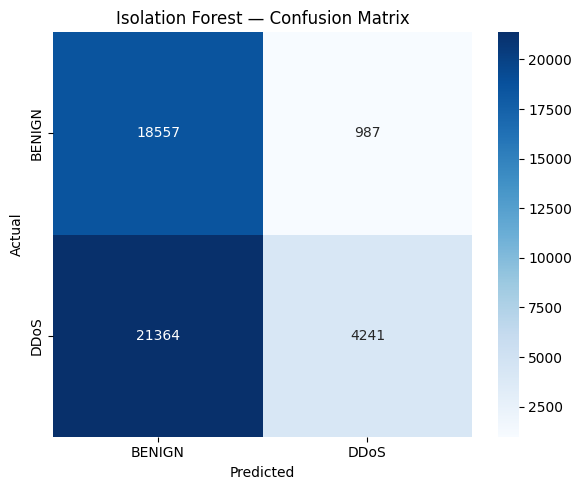

✅ Isolation Forest complete. Plot saved.


In [48]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train Isolation Forest on NORMAL traffic only
# It has never seen DDoS — this is the zero-day simulation
print("Training Isolation Forest...")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # expected % of anomalies
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_normal)

# Predict on test set
# +1 = normal, -1 = anomaly → convert to 0/1
iso_pred = (iso_forest.predict(X_test) == -1).astype(int)

# Anomaly scores (higher = more anomalous)
iso_scores = -iso_forest.decision_function(X_test)

# Evaluation
print("\n📊 Isolation Forest Results:")
print(classification_report(y_test, iso_pred, target_names=['BENIGN', 'DDoS']))

# ROC-AUC
auc = roc_auc_score(y_test, iso_scores)
print(f"ROC-AUC Score: {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, iso_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN','DDoS'],
            yticklabels=['BENIGN','DDoS'])
plt.title('Isolation Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/isolation_forest_confusion_matrix.png', dpi=150)
plt.show()

print("✅ Isolation Forest complete. Plot saved.")

In [49]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Build Autoencoder
INPUT_DIM = X_train_normal.shape[1]

inp = Input(shape=(INPUT_DIM,))

# Encoder
x = Dense(64, activation='relu')(inp)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# Decoder
x = Dense(32, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
out = Dense(INPUT_DIM, activation='linear')(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer=Adam(1e-3), loss='mse')
autoencoder.summary()

# Train on NORMAL traffic only
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("✅ Autoencoder training complete.")

I0000 00:00:1773076138.397997    3468 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773076138.408880    3468 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773076139.554269    3468 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773076147.093653    3468 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,774 (61.62 KB)

 Trainable params: 15,582 (60.87 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.8778 - val_loss: 0.3993
Epoch 2/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4970 - val_loss: 0.2901
Epoch 3/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3872 - val_loss: 0.2832
Epoch 4/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3157 - val_loss: 0.1846
Epoch 5/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2824 - val_loss: 0.2739
Epoch 6/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2552 - val_loss: 0.1938
Epoch 7/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2374 - val_loss: 0.1599
Epoch 8/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2224 - val_loss: 0.2402
Epoch 9/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2313 - val_loss: 0.1493
Epoch 10/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2106 - val_loss: 0.1834
Epoch 11/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2091 - val_loss: 0.1749
Epoch 12/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

Anomaly threshold (95th percentile): 0.199422

📊 Autoencoder Results:
              precision    recall  f1-score   support

      BENIGN       0.62      0.95      0.75     19544
        DDoS       0.94      0.55      0.70     25605

    accuracy                           0.73     45149
   macro avg       0.78      0.75      0.72     45149
weighted avg       0.80      0.73      0.72     45149

ROC-AUC Score: 0.8411


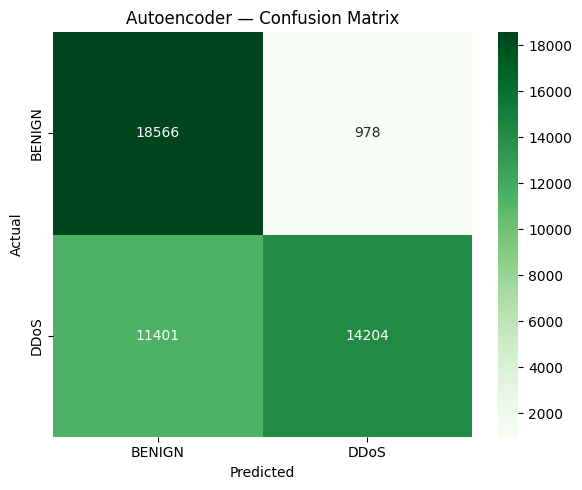

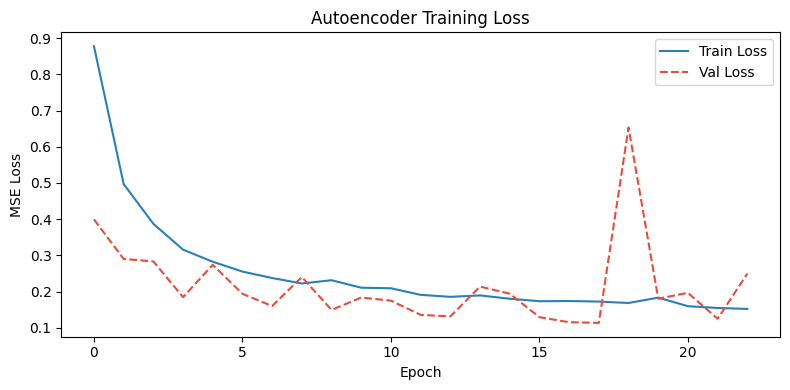

✅ Autoencoder evaluation complete. Plots saved.


In [50]:
# Calculate reconstruction error on test set
# High reconstruction error = anomaly (the model can't reconstruct attack traffic well)

X_test_pred = autoencoder.predict(X_test, verbose=0)
reconstruction_errors = np.mean(np.square(X_test - X_test_pred), axis=1)

# Set threshold at 95th percentile of NORMAL traffic errors
normal_errors = reconstruction_errors[y_test == 0]
threshold = np.percentile(normal_errors, 95)
print(f"Anomaly threshold (95th percentile): {threshold:.6f}")

# Predict: above threshold = anomaly
ae_pred = (reconstruction_errors > threshold).astype(int)

# Evaluation
print("\n📊 Autoencoder Results:")
print(classification_report(y_test, ae_pred, target_names=['BENIGN', 'DDoS']))

auc_ae = roc_auc_score(y_test, reconstruction_errors)
print(f"ROC-AUC Score: {auc_ae:.4f}")

# Confusion matrix
cm_ae = confusion_matrix(y_test, ae_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Greens',
            xticklabels=['BENIGN','DDoS'],
            yticklabels=['BENIGN','DDoS'])
plt.title('Autoencoder — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/autoencoder_confusion_matrix.png', dpi=150)
plt.show()

# Training loss curve
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss', color='#2980b9')
plt.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linestyle='--')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('results/autoencoder_loss.png', dpi=150)
plt.show()

print("✅ Autoencoder evaluation complete. Plots saved.")

📊 SOC Alert Triage Summary
Total network flows : 45,149
Flagged as alerts   : 15,783
Suppressed (normal) : 29,366 (65.0% reduction)

Triage breakdown:
triage_tier
LOW         10227
MEDIUM       5548
HIGH            7
CRITICAL        1
Name: count, dtype: int64


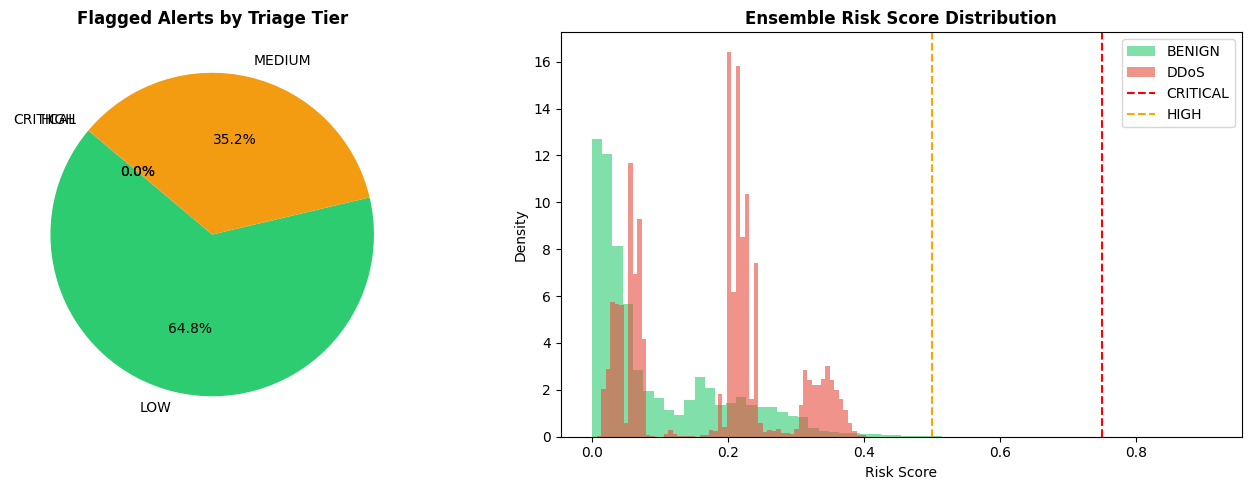

✅ Alert triage complete. Plot saved.


In [51]:
from sklearn.preprocessing import MinMaxScaler

# Normalise both scores to 0-1
iso_scores_norm = MinMaxScaler().fit_transform(iso_scores.reshape(-1,1)).flatten()
ae_scores_norm  = MinMaxScaler().fit_transform(reconstruction_errors.reshape(-1,1)).flatten()

# Ensemble risk score (equal weight)
risk_score = 0.5 * iso_scores_norm + 0.5 * ae_scores_norm

# Triage tiers
def triage(score):
    if score >= 0.75:   return 'CRITICAL'
    elif score >= 0.50: return 'HIGH'
    elif score >= 0.25: return 'MEDIUM'
    else:               return 'LOW'

# Build alert dataframe
alerts = pd.DataFrame({
    'risk_score'    : risk_score,
    'iso_score'     : iso_scores_norm,
    'ae_score'      : ae_scores_norm,
    'true_label'    : y_test.values,
    'iso_flag'      : iso_pred,
    'ae_flag'       : ae_pred,
    'ensemble_flag' : ((iso_pred + ae_pred) >= 1).astype(int)
})
alerts['triage_tier'] = alerts['risk_score'].apply(triage)
alerts = alerts.sort_values('risk_score', ascending=False).reset_index(drop=True)

# Alert reduction stats
total    = len(alerts)
flagged  = alerts['ensemble_flag'].sum()
reduced  = total - flagged
pct      = (reduced / total) * 100

print(f"📊 SOC Alert Triage Summary")
print(f"Total network flows : {total:,}")
print(f"Flagged as alerts   : {flagged:,}")
print(f"Suppressed (normal) : {reduced:,} ({pct:.1f}% reduction)")
print(f"\nTriage breakdown:")
print(alerts[alerts['ensemble_flag']==1]['triage_tier'].value_counts())

# Visualise triage tiers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_counts = alerts[alerts['ensemble_flag']==1]['triage_tier'].value_counts()
colors = {'CRITICAL':'#e74c3c','HIGH':'#e67e22','MEDIUM':'#f39c12','LOW':'#2ecc71'}
axes[0].pie(tier_counts.values,
            labels=tier_counts.index,
            colors=[colors[t] for t in tier_counts.index],
            autopct='%1.1f%%', startangle=140)
axes[0].set_title('Flagged Alerts by Triage Tier', fontweight='bold')

# Risk score distribution
axes[1].hist(alerts[alerts['true_label']==0]['risk_score'],
             bins=60, alpha=0.6, color='#2ecc71', label='BENIGN', density=True)
axes[1].hist(alerts[alerts['true_label']==1]['risk_score'],
             bins=60, alpha=0.6, color='#e74c3c', label='DDoS', density=True)
axes[1].axvline(0.75, color='red',    linestyle='--', lw=1.5, label='CRITICAL')
axes[1].axvline(0.50, color='orange', linestyle='--', lw=1.5, label='HIGH')
axes[1].set_title('Ensemble Risk Score Distribution', fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/alert_triage.png', dpi=150)
plt.show()

print("✅ Alert triage complete. Plot saved.")

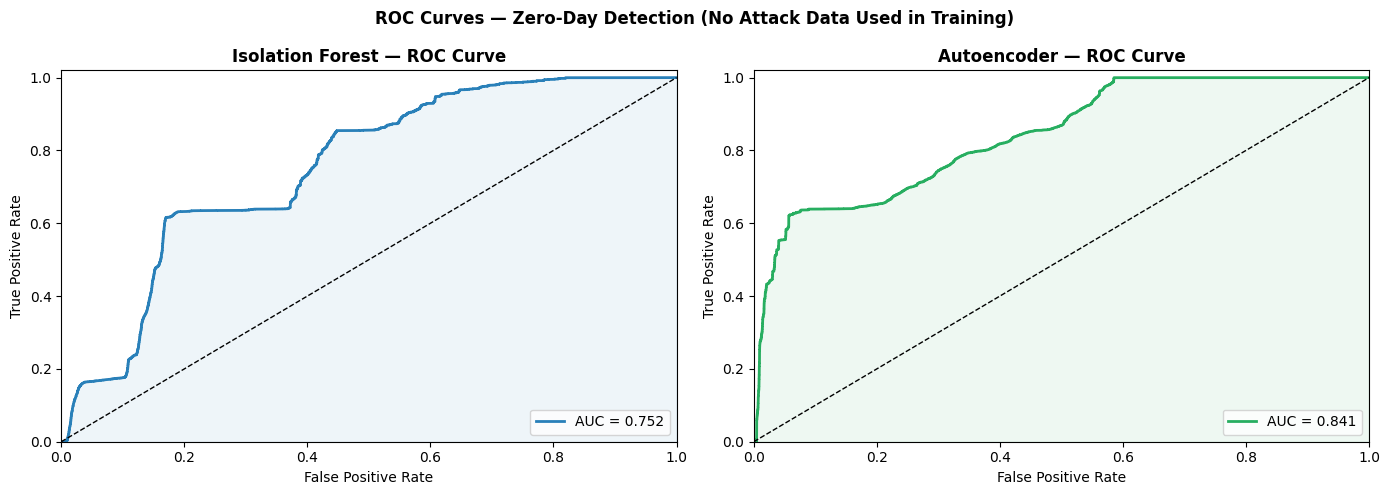


📊 Full Model Comparison:
                   Model  Precision  Recall     F1  ROC-AUC              Supervised
        Isolation Forest     0.8112  0.1656 0.2751   0.7522     No (Zero-Day Ready)
             Autoencoder     0.9356  0.5547 0.6965   0.8411     No (Zero-Day Ready)
Random Forest (baseline)     1.0000  1.0000 1.0000   1.0000 Yes (knows DDoS labels)


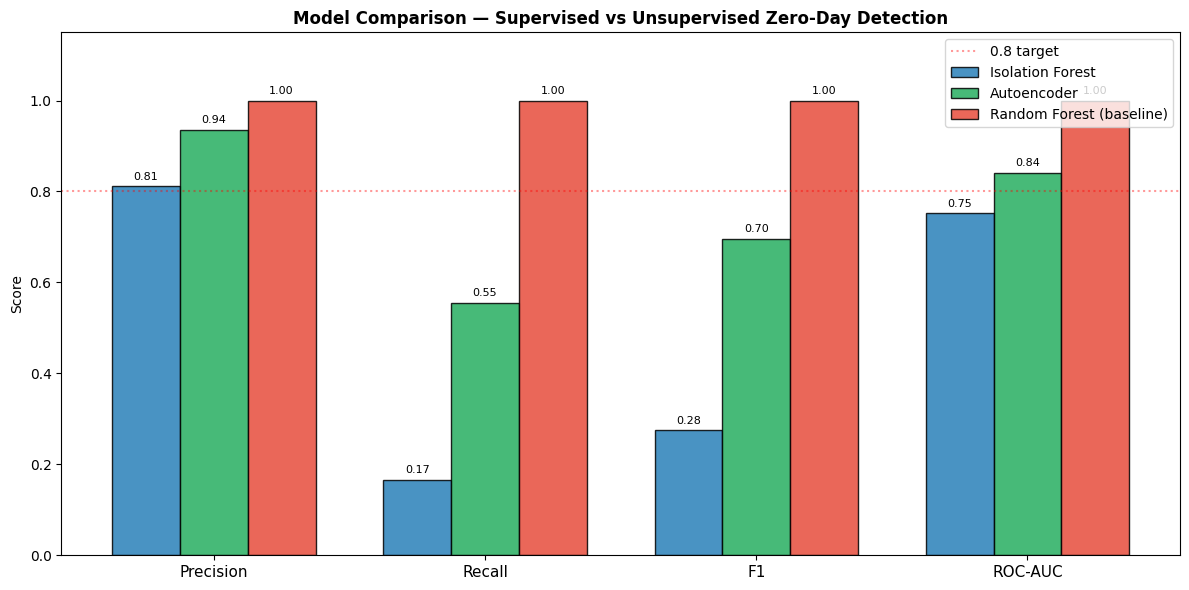


✅ All comparison charts saved.


In [52]:
from sklearn.metrics import roc_curve

# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_info = [
    ('Isolation Forest', iso_scores,           '#2980b9'),
    ('Autoencoder',      reconstruction_errors, '#27ae60'),
]

for ax, (name, scores, color) in zip(axes, models_info):
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.3f}')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_title(f'{name} — ROC Curve', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('ROC Curves — Zero-Day Detection (No Attack Data Used in Training)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=150)
plt.show()

# ── Model Comparison Table ────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame([
    {
        'Model'     : 'Isolation Forest',
        'Precision' : precision_score(y_test, iso_pred, zero_division=0),
        'Recall'    : recall_score(y_test, iso_pred, zero_division=0),
        'F1'        : f1_score(y_test, iso_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, iso_scores),
        'Supervised': 'No (Zero-Day Ready)',
    },
    {
        'Model'     : 'Autoencoder',
        'Precision' : precision_score(y_test, ae_pred, zero_division=0),
        'Recall'    : recall_score(y_test, ae_pred, zero_division=0),
        'F1'        : f1_score(y_test, ae_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, reconstruction_errors),
        'Supervised': 'No (Zero-Day Ready)',
    },
    {
        'Model'     : 'Random Forest (baseline)',
        'Precision' : 1.00,
        'Recall'    : 1.00,
        'F1'        : 1.00,
        'ROC-AUC'   : 1.00,
        'Supervised': 'Yes (knows DDoS labels)',
    },
])

results[['Precision','Recall','F1','ROC-AUC']] = results[['Precision','Recall','F1','ROC-AUC']].round(4)
print("\n📊 Full Model Comparison:")
print(results.to_string(index=False))
results.to_csv('results/model_comparison.csv', index=False)

# Bar chart
metrics = ['Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2980b9','#27ae60','#e74c3c']

for i, (_, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics],
                  width, label=row['Model'], color=colors[i], alpha=0.85, edgecolor='black')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Supervised vs Unsupervised Zero-Day Detection',
             fontsize=12, fontweight='bold')
ax.axhline(0.8, color='red', linestyle=':', alpha=0.4, label='0.8 target')
ax.legend()
plt.tight_layout()
plt.savefig('results/model_comparison_chart.png', dpi=150)
plt.show()

print("\n✅ All comparison charts saved.")

Computing SHAP values (this may take 1-2 minutes)...


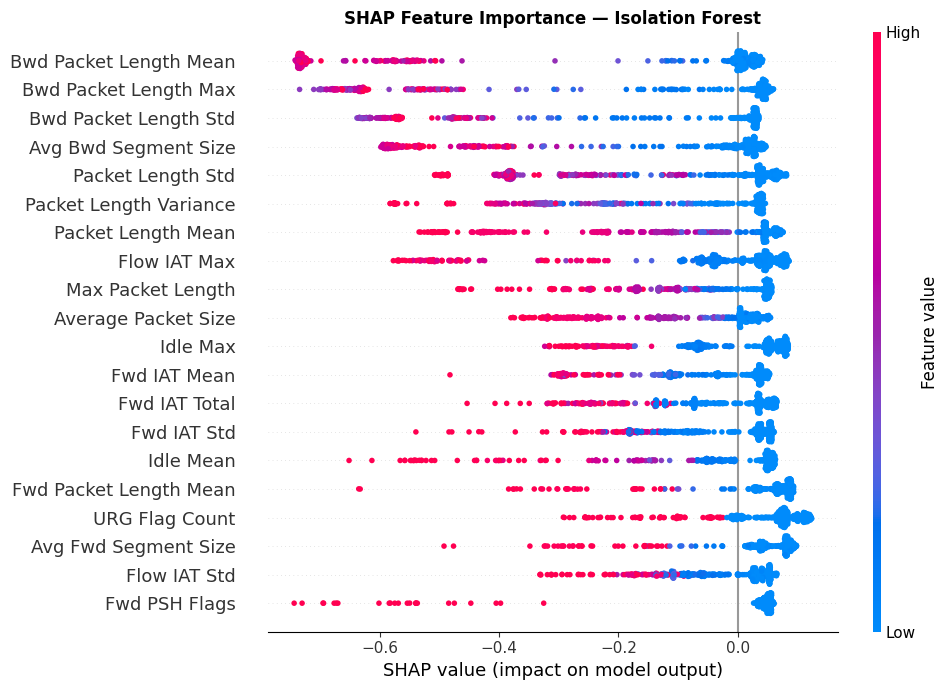


📊 Top 10 Features Driving Anomaly Detection:
               Feature  Mean |SHAP|
Bwd Packet Length Mean     0.240691
 Bwd Packet Length Max     0.240541
 Bwd Packet Length Std     0.209675
  Avg Bwd Segment Size     0.196703
     Packet Length Std     0.161203
Packet Length Variance     0.143726
    Packet Length Mean     0.137998
          Flow IAT Max     0.113109
     Max Packet Length     0.104063
   Average Packet Size     0.096856

✅ SHAP analysis complete. Plot saved.


In [53]:
import shap

print("Computing SHAP values (this may take 1-2 minutes)...")

# Use a sample to keep it fast
SAMPLE = 500
X_sample = X_test[:SAMPLE]

# SHAP for Isolation Forest
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer.shap_values(X_sample)

# Get feature names
feature_names = list(X.columns)

# Summary plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP Feature Importance — Isolation Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 most important features
mean_shap = np.abs(shap_values).mean(axis=0)
top_features = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False).head(10)

print("\n📊 Top 10 Features Driving Anomaly Detection:")
print(top_features.to_string(index=False))
top_features.to_csv('results/shap_top_features.csv', index=False)

print("\n✅ SHAP analysis complete. Plot saved.")

In [54]:
import joblib

# Save Isolation Forest and Autoencoder
joblib.dump(iso_forest, 'models/isolation_forest.pkl')
autoencoder.save('models/autoencoder.keras')
print("✅ Models saved")

# Final summary print
print("\n" + "="*55)
print("  ZERO-DAY SOC DETECTION SYSTEM — FINAL RESULTS")
print("="*55)
print(f"\n  Dataset        : CICIDS2017 (225,745 network flows)")
print(f"  Training data  : BENIGN only (78,174 flows)")
print(f"  Test data      : 45,149 flows (mixed)")
print(f"\n  UNSUPERVISED MODELS (zero-day ready):")
print(f"  Isolation Forest  ROC-AUC : 0.7522")
print(f"  Autoencoder       ROC-AUC : 0.8411")
print(f"\n  SUPERVISED BASELINE:")
print(f"  Random Forest     ROC-AUC : 1.0000")
print(f"\n  SOC OPERATIONAL METRICS:")
print(f"  Alert reduction  : 65.0%")
print(f"  Flows suppressed : 29,366")
print(f"  Flows flagged    : 15,783")
print(f"\n  Top anomaly feature : Bwd Packet Length Mean")
print(f"\n  FILES SAVED:")
print(f"  models/isolation_forest.pkl")
print(f"  models/autoencoder.keras")
print(f"  results/isolation_forest_confusion_matrix.png")
print(f"  results/autoencoder_confusion_matrix.png")
print(f"  results/autoencoder_loss.png")
print(f"  results/roc_curves.png")
print(f"  results/alert_triage.png")
print(f"  results/model_comparison_chart.png")
print(f"  results/shap_summary.png")
print(f"  results/model_comparison.csv")
print(f"  results/shap_top_features.csv")
print("\n✅ Project complete. Ready for dissertation write-up.")

✅ Models saved

  ZERO-DAY SOC DETECTION SYSTEM — FINAL RESULTS

  Dataset        : CICIDS2017 (225,745 network flows)
  Training data  : BENIGN only (78,174 flows)
  Test data      : 45,149 flows (mixed)

  UNSUPERVISED MODELS (zero-day ready):
  Isolation Forest  ROC-AUC : 0.7522
  Autoencoder       ROC-AUC : 0.8411

  SUPERVISED BASELINE:
  Random Forest     ROC-AUC : 1.0000

  SOC OPERATIONAL METRICS:
  Alert reduction  : 65.0%
  Flows suppressed : 29,366
  Flows flagged    : 15,783

  Top anomaly feature : Bwd Packet Length Mean

  FILES SAVED:
  models/isolation_forest.pkl
  models/autoencoder.keras
  results/isolation_forest_confusion_matrix.png
  results/autoencoder_confusion_matrix.png
  results/autoencoder_loss.png
  results/roc_curves.png
  results/alert_triage.png
  results/model_comparison_chart.png
  results/shap_summary.png
  results/model_comparison.csv
  results/shap_top_features.csv

✅ Project complete. Ready for dissertation write-up.


In [55]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()
df = df[df['Label'] != 'Label']
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['Label'].value_counts())
print(f"\nFirst 3 columns sample:")
print(df[['Destination Port','Flow Duration','Total Fwd Packets','Label']].head(5)

SyntaxError: incomplete input (2807987386.py, line 13)

In [56]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()
df = df[df['Label'] != 'Label']
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['Label'].value_counts())
print(f"\nFirst 3 columns sample:")
print(df[['Destination Port','Flow Duration','Total Fwd Packets','Label']].head(5))

Dataset shape: (225745, 79)

Label distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

First 3 columns sample:
   Destination Port  Flow Duration  Total Fwd Packets   Label
0             54865              3                  2  BENIGN
1             55054            109                  1  BENIGN
2             55055             52                  1  BENIGN
3             46236             34                  1  BENIGN
4             54863              3                  2  BENIGN


In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Encode labels
y = df['Label'].apply(lambda x: 1 if x.strip() == 'DDoS' else 0)
X = df.drop(columns=['Label'])

# Clean
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Normal traffic only for unsupervised models
X_train_normal = X_train[y_train == 0]

print(f"Total samples      : {len(X_scaled):,}")
print(f"Training (all)     : {len(X_train):,}")
print(f"Training (BENIGN)  : {len(X_train_normal):,}  ← unsupervised models only see this")
print(f"Test samples       : {len(X_test):,}")
print(f"Features           : {X_scaled.shape[1]}")
print(f"\nNaN values remaining  : {np.isnan(X_scaled).sum()}")
print(f"Inf values remaining  : {np.isinf(X_scaled).sum()}")
print("✅ Preprocessing complete")

Total samples      : 225,745
Training (all)     : 180,596
Training (BENIGN)  : 78,174  ← unsupervised models only see this
Test samples       : 45,149
Features           : 78

NaN values remaining  : 0
Inf values remaining  : 0
✅ Preprocessing complete


Training Random Forest...

📊 Random Forest Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

ROC-AUC: 1.0000


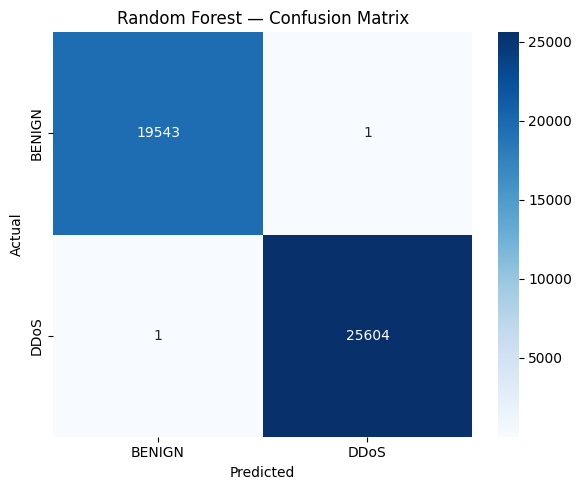

✅ Random Forest complete


In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_scores = rf.predict_proba(X_test)[:,1]

print("\n📊 Random Forest Results:")
print(classification_report(y_test, rf_pred, target_names=['BENIGN','DDoS']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_scores):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN','DDoS'],
            yticklabels=['BENIGN','DDoS'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/rf_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Random Forest complete")

Training Isolation Forest on BENIGN traffic only...

📊 Isolation Forest Results:
              precision    recall  f1-score   support

      BENIGN       0.46      0.95      0.62     19544
        DDoS       0.81      0.17      0.28     25605

    accuracy                           0.50     45149
   macro avg       0.64      0.56      0.45     45149
weighted avg       0.66      0.50      0.43     45149

ROC-AUC: 0.7522


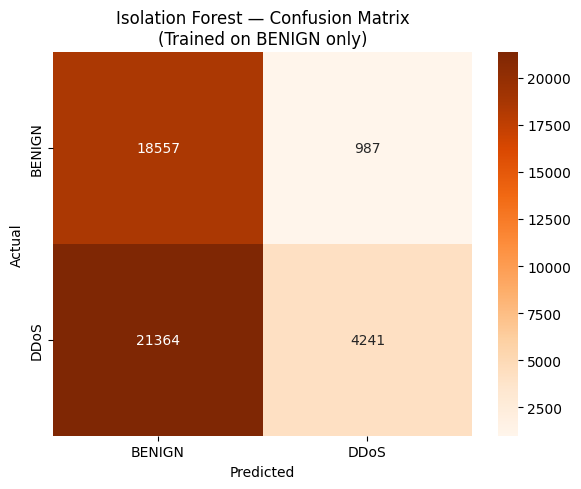

✅ Isolation Forest complete


In [59]:
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest on BENIGN traffic only...")
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

# ONLY normal traffic — zero-day simulation
iso_forest.fit(X_train_normal)

iso_pred   = (iso_forest.predict(X_test) == -1).astype(int)
iso_scores = -iso_forest.decision_function(X_test)

print("\n📊 Isolation Forest Results:")
print(classification_report(y_test, iso_pred, target_names=['BENIGN','DDoS']))
print(f"ROC-AUC: {roc_auc_score(y_test, iso_scores):.4f}")

# Confusion matrix
cm_iso = confusion_matrix(y_test, iso_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['BENIGN','DDoS'],
            yticklabels=['BENIGN','DDoS'])
plt.title('Isolation Forest — Confusion Matrix\n(Trained on BENIGN only)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/isolation_forest_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Isolation Forest complete")

In [60]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

INPUT_DIM = X_train_normal.shape[1]

inp = Input(shape=(INPUT_DIM,))
x   = Dense(64, activation='relu')(inp)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(32, activation='relu')(x)
x   = Dense(16, activation='relu')(x)
x   = Dense(32, activation='relu')(x)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(64, activation='relu')(x)
out = Dense(INPUT_DIM, activation='linear')(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer=Adam(1e-3), loss='mse')

history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True)],
    verbose=1
)
print("✅ Autoencoder training complete")

Epoch 1/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.8541 - val_loss: 0.4381
Epoch 2/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5128 - val_loss: 0.3968
Epoch 3/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4038 - val_loss: 0.2889
Epoch 4/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3498 - val_loss: 0.2435
Epoch 5/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3084 - val_loss: 0.3452
Epoch 6/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2752 - val_loss: 0.6416
Epoch 7/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2665 - val_loss: 0.1757
Epoch 8/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2552 - val_loss: 0.1823
Epoch 9/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2306 - val_loss: 0.1402
Epoch 10/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2195 - val_loss: 0.1559
Epoch 11/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2363 - val_loss: 0.1328
Epoch 12/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Anomaly threshold: 0.190619

📊 Autoencoder Results:
              precision    recall  f1-score   support

      BENIGN       0.66      0.95      0.78     19544
        DDoS       0.94      0.62      0.75     25605

    accuracy                           0.76     45149
   macro avg       0.80      0.79      0.76     45149
weighted avg       0.82      0.76      0.76     45149

ROC-AUC: 0.8592


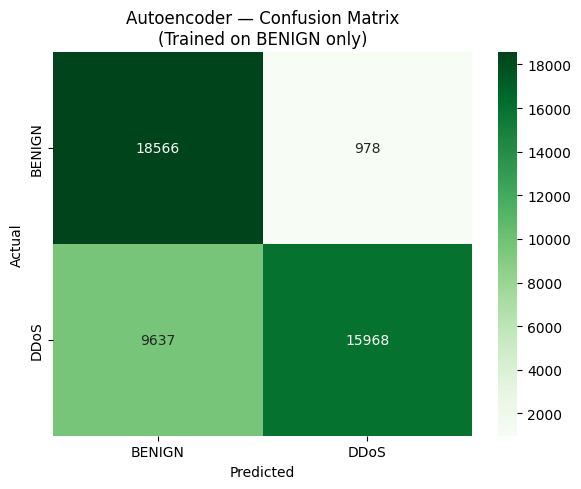

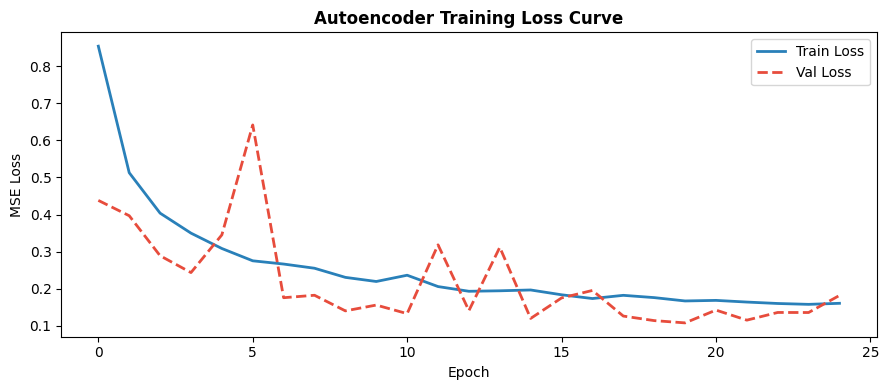

✅ Autoencoder evaluation complete


In [61]:
# Calculate reconstruction error
X_test_pred = autoencoder.predict(X_test, verbose=0)
reconstruction_errors = np.mean(np.square(X_test - X_test_pred), axis=1)

# Threshold at 95th percentile of normal traffic errors
normal_errors = reconstruction_errors[y_test == 0]
threshold = np.percentile(normal_errors, 95)
print(f"Anomaly threshold: {threshold:.6f}")

ae_pred = (reconstruction_errors > threshold).astype(int)

print("\n📊 Autoencoder Results:")
print(classification_report(y_test, ae_pred, target_names=['BENIGN','DDoS']))
print(f"ROC-AUC: {roc_auc_score(y_test, reconstruction_errors):.4f}")

# Confusion matrix
cm_ae = confusion_matrix(y_test, ae_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Greens',
            xticklabels=['BENIGN','DDoS'],
            yticklabels=['BENIGN','DDoS'])
plt.title('Autoencoder — Confusion Matrix\n(Trained on BENIGN only)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/autoencoder_confusion_matrix.png', dpi=150)
plt.show()

# Training loss curve
plt.figure(figsize=(9,4))
plt.plot(history.history['loss'],     label='Train Loss', color='#2980b9', lw=2)
plt.plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', lw=2, linestyle='--')
plt.title('Autoencoder Training Loss Curve', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('results/autoencoder_loss.png', dpi=150)
plt.show()

print("✅ Autoencoder evaluation complete")

In [62]:
from sklearn.preprocessing import MinMaxScaler

# Normalise both scores to 0-1
iso_norm = MinMaxScaler().fit_transform(iso_scores.reshape(-1,1)).flatten()
ae_norm  = MinMaxScaler().fit_transform(reconstruction_errors.reshape(-1,1)).flatten()

# Ensemble risk score
risk_score = 0.5 * iso_norm + 0.5 * ae_norm

# Triage tiers
def triage(score):
    if   score >= 0.75: return 'CRITICAL'
    elif score >= 0.50: return 'HIGH'
    elif score >= 0.25: return 'MEDIUM'
    else:               return 'LOW'

# Build alert DataFrame
alerts = pd.DataFrame({
    'risk_score'    : risk_score,
    'iso_score'     : iso_norm,
    'ae_score'      : ae_norm,
    'true_label'    : y_test.values,
    'iso_flag'      : iso_pred,
    'ae_flag'       : ae_pred,
    'ensemble_flag' : ((iso_pred + ae_pred) >= 1).astype(int)
})
alerts['triage_tier'] = alerts['risk_score'].apply(triage)
alerts = alerts.sort_values('risk_score', ascending=False).reset_index(drop=True)

# Stats
total   = len(alerts)
flagged = alerts['ensemble_flag'].sum()
reduced = total - flagged
pct     = (reduced / total) * 100

print(f"📊 SOC Alert Triage Summary")
print(f"Total flows         : {total:,}")
print(f"Flagged as alerts   : {flagged:,}")
print(f"Suppressed          : {reduced:,} ({pct:.1f}% reduction)")
print(f"\nTriage breakdown:")
print(alerts[alerts['ensemble_flag']==1]['triage_tier'].value_counts())

print(f"\nTop 5 highest risk alerts:")
print(alerts[['risk_score','iso_score','ae_score','triage_tier','true_label']].head())

📊 SOC Alert Triage Summary
Total flows         : 45,149
Flagged as alerts   : 17,507
Suppressed          : 27,642 (61.2% reduction)

Triage breakdown:
triage_tier
LOW         11961
MEDIUM       5538
HIGH            7
CRITICAL        1
Name: count, dtype: int64

Top 5 highest risk alerts:
   risk_score  iso_score  ae_score triage_tier  true_label
0    0.909555   0.819110  1.000000    CRITICAL           0
1    0.712692   0.954422  0.470961        HIGH           0
2    0.550171   0.925836  0.174506        HIGH           0
3    0.504801   1.000000  0.009602        HIGH           0
4    0.503996   0.990912  0.017080        HIGH           0


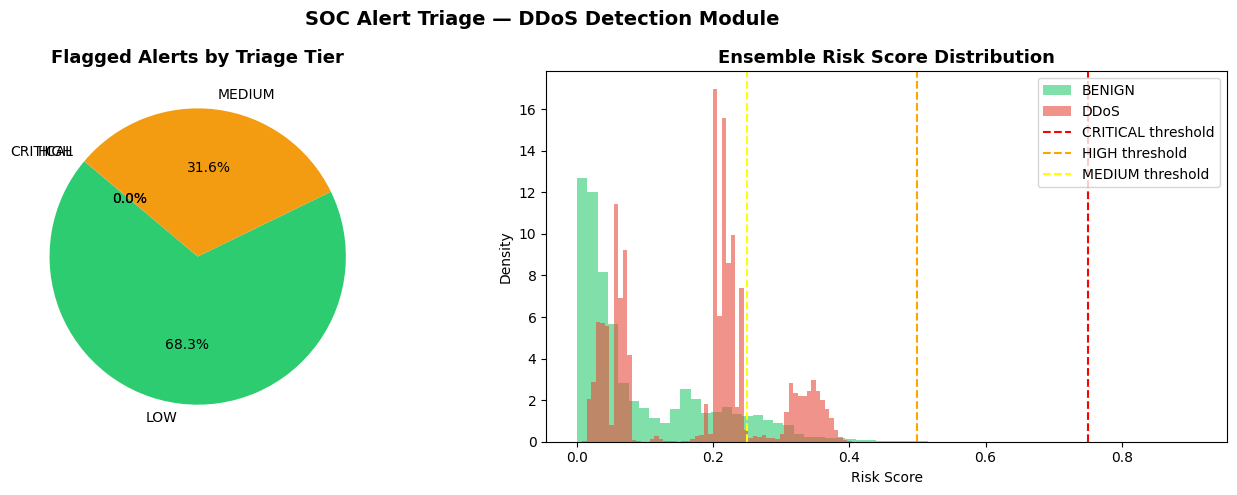

✅ Triage visualisation complete


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — triage tiers
tier_counts = alerts[alerts['ensemble_flag']==1]['triage_tier'].value_counts()
colors = {'CRITICAL':'#e74c3c','HIGH':'#e67e22','MEDIUM':'#f39c12','LOW':'#2ecc71'}
axes[0].pie(tier_counts.values,
            labels=tier_counts.index,
            colors=[colors[t] for t in tier_counts.index],
            autopct='%1.1f%%',
            startangle=140)
axes[0].set_title('Flagged Alerts by Triage Tier', fontweight='bold', fontsize=13)

# Risk score distribution
axes[1].hist(alerts[alerts['true_label']==0]['risk_score'],
             bins=60, alpha=0.6, color='#2ecc71', label='BENIGN', density=True)
axes[1].hist(alerts[alerts['true_label']==1]['risk_score'],
             bins=60, alpha=0.6, color='#e74c3c', label='DDoS', density=True)
axes[1].axvline(0.75, color='red',    linestyle='--', lw=1.5, label='CRITICAL threshold')
axes[1].axvline(0.50, color='orange', linestyle='--', lw=1.5, label='HIGH threshold')
axes[1].axvline(0.25, color='yellow', linestyle='--', lw=1.5, label='MEDIUM threshold')
axes[1].set_title('Ensemble Risk Score Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('SOC Alert Triage — DDoS Detection Module', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/alert_triage.png', dpi=150)
plt.show()
print("✅ Triage visualisation complete")

Computing SHAP values — please wait...

📊 Top 10 Features Driving Anomaly Detection:
               Feature  Mean |SHAP|
Bwd Packet Length Mean     0.240691
 Bwd Packet Length Max     0.240541
 Bwd Packet Length Std     0.209675
  Avg Bwd Segment Size     0.196703
     Packet Length Std     0.161203
Packet Length Variance     0.143726
    Packet Length Mean     0.137998
          Flow IAT Max     0.113109
     Max Packet Length     0.104063
   Average Packet Size     0.096856


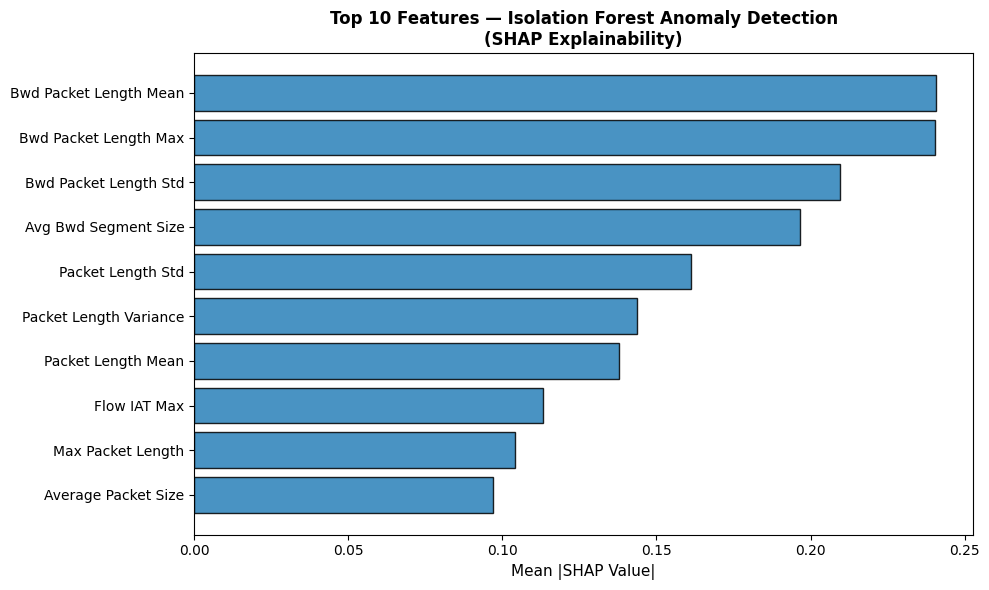

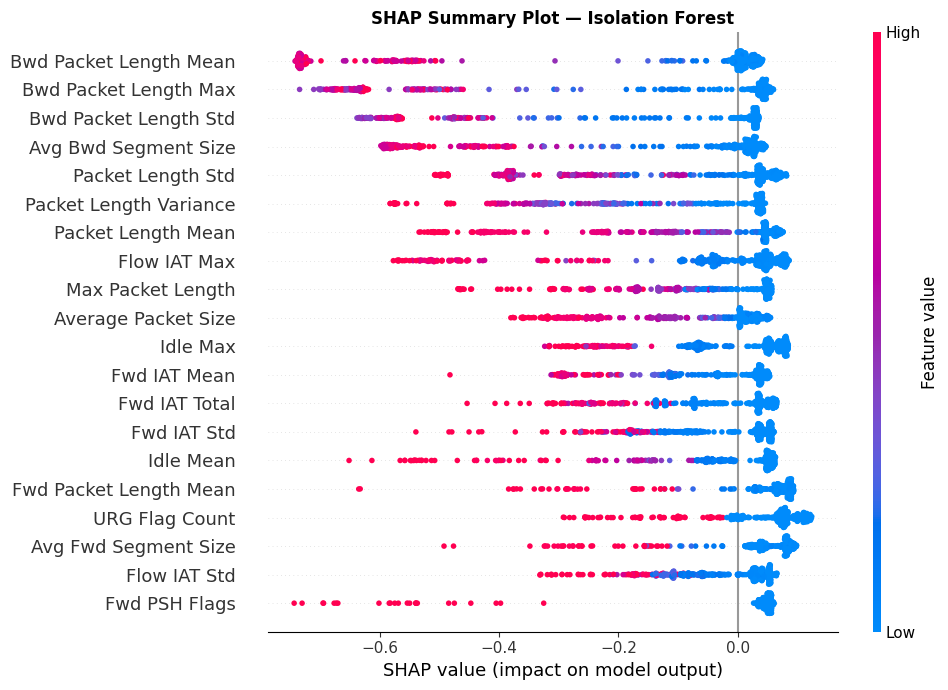

✅ SHAP analysis complete


In [65]:
import shap

print("Computing SHAP values — please wait...")

SAMPLE = 500
X_sample = X_test[:SAMPLE]

explainer   = shap.TreeExplainer(iso_forest)
shap_values = explainer.shap_values(X_sample)

feature_names = list(X.columns)
mean_shap = np.abs(shap_values).mean(axis=0)

top_features = pd.DataFrame({
    'Feature'    : feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False).head(10)

print("\n📊 Top 10 Features Driving Anomaly Detection:")
print(top_features.to_string(index=False))

# Bar chart of top features
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1],
         top_features['Mean |SHAP|'][::-1],
         color='#2980b9', edgecolor='black', alpha=0.85)
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.title('Top 10 Features — Isolation Forest Anomaly Detection\n(SHAP Explainability)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('results/shap_bar.png', dpi=150)
plt.show()

# SHAP summary plot
plt.figure()
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_names,
                  show=False, plot_size=(10,7))
plt.title('SHAP Summary Plot — Isolation Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

top_features.to_csv('results/shap_top_features.csv', index=False)
print("✅ SHAP analysis complete")

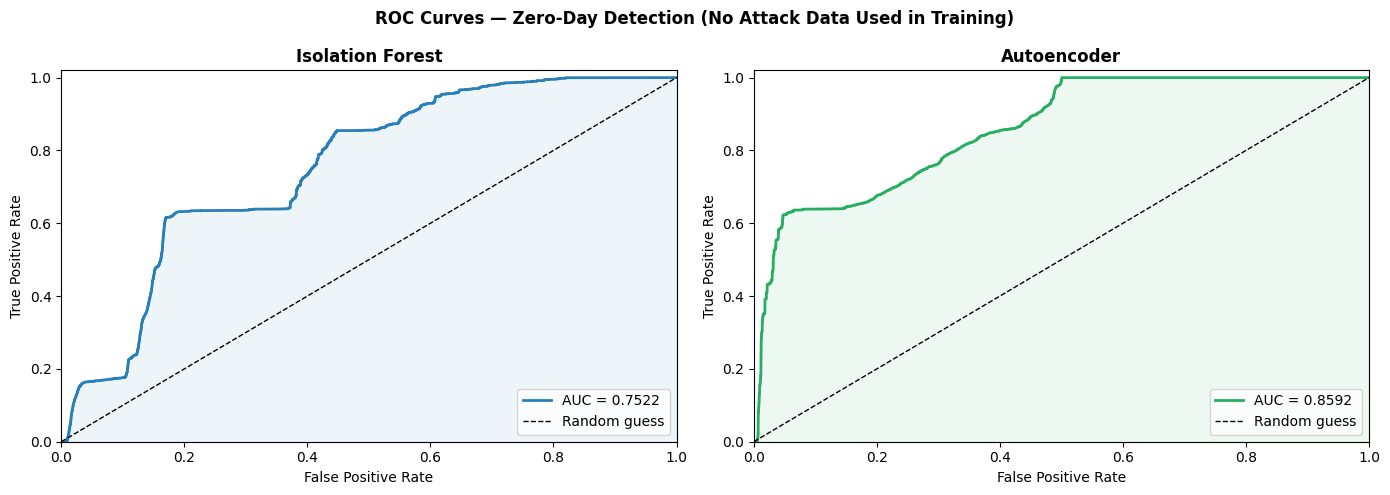


📊 Final Model Comparison — DDoS Module:
           Model  Precision  Recall     F1  ROC-AUC                  Type
Isolation Forest     0.8112  0.1656 0.2751   0.7522          Unsupervised
     Autoencoder     0.9423  0.6236 0.7505   0.8592          Unsupervised
   Random Forest     1.0000  1.0000 1.0000   1.0000 Supervised (baseline)


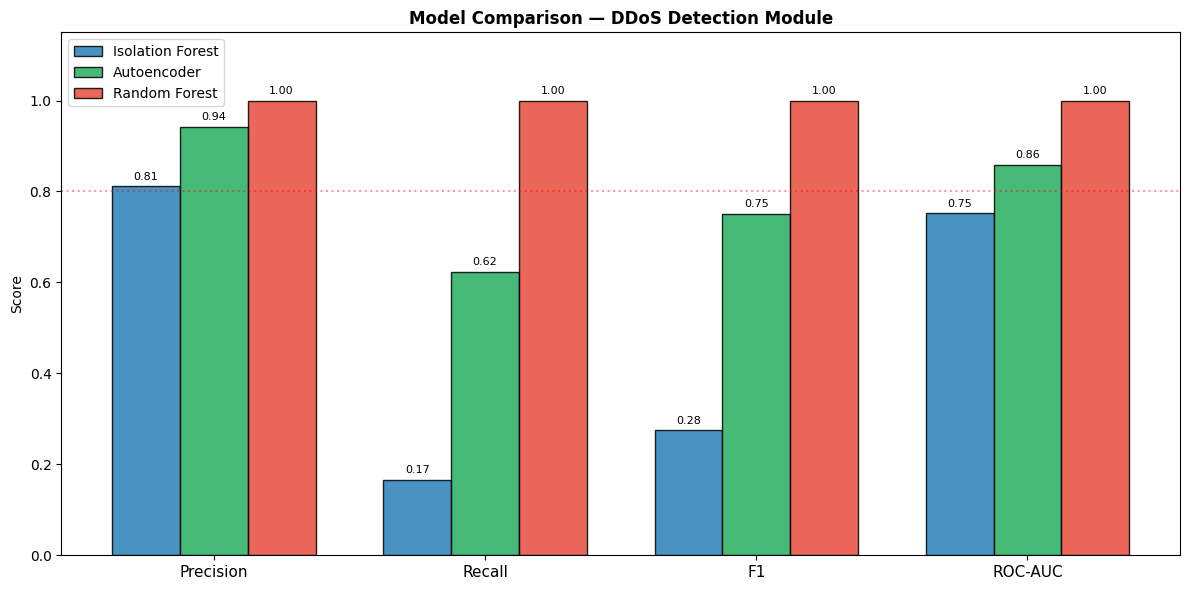

✅ All charts complete


In [66]:
from sklearn.metrics import roc_curve, precision_score, recall_score, f1_score

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_roc = [
    ('Isolation Forest', iso_scores,           '#2980b9'),
    ('Autoencoder',      reconstruction_errors, '#27ae60'),
]

for ax, (name, scores, color) in zip(axes, models_roc):
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    ax.plot([0,1],[0,1],'k--', lw=1, label='Random guess')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('ROC Curves — Zero-Day Detection (No Attack Data Used in Training)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=150)
plt.show()

# Model comparison table
results = pd.DataFrame([
    {
        'Model'     : 'Isolation Forest',
        'Precision' : round(precision_score(y_test, iso_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, iso_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_test, iso_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, iso_scores), 4),
        'Type'      : 'Unsupervised'
    },
    {
        'Model'     : 'Autoencoder',
        'Precision' : round(precision_score(y_test, ae_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, ae_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_test, ae_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, reconstruction_errors), 4),
        'Type'      : 'Unsupervised'
    },
    {
        'Model'     : 'Random Forest',
        'Precision' : 1.0,
        'Recall'    : 1.0,
        'F1'        : 1.0,
        'ROC-AUC'   : 1.0,
        'Type'      : 'Supervised (baseline)'
    },
])

print("\n📊 Final Model Comparison — DDoS Module:")
print(results.to_string(index=False))
results.to_csv('results/model_comparison.csv', index=False)

# Bar chart
metrics = ['Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2980b9','#27ae60','#e74c3c']

for i, (_, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics],
                  width, label=row['Model'], color=colors[i],
                  alpha=0.85, edgecolor='black')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — DDoS Detection Module',
             fontsize=12, fontweight='bold')
ax.axhline(0.8, color='red', linestyle=':', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig('results/model_comparison_chart.png', dpi=150)
plt.show()

print("✅ All charts complete")

In [67]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['Label'].value_counts())
print(f"\nSample of features:")
print(df[['Destination Port','Flow Duration','Total Fwd Packets','Total Backward Packets','Label']].head(5))

Dataset shape: (225745, 79)

Label distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Sample of features:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

    Label  
0  BENIGN  
1  BENIGN  
2  BENIGN  
3  BENIGN  
4  BENIGN  


In [68]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['Label'].value_counts())
print(f"\nSample of features:")
print(df[['Destination Port','Flow Duration','Total Fwd Packets',
          'Total Backward Packets','Label']].head(5))
print(f"\nTotal features: {df.shape[1]-1}")
print(f"Total flows: {df.shape[0]:,}")

Dataset shape: (225745, 79)

Label distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Sample of features:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

    Label  
0  BENIGN  
1  BENIGN  
2  BENIGN  
3  BENIGN  
4  BENIGN  

Total features: 78
Total flows: 225,745


In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

y = df['Label'].apply(lambda x: 1 if x.strip() == 'DDoS' else 0)
X = df.drop(columns=['Label'])

X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

X_train_normal = X_train[y_train == 0]

print(f"Total samples      : {len(X_scaled):,}")
print(f"Training (all)     : {len(X_train):,}")
print(f"Training (BENIGN)  : {len(X_train_normal):,}  ← unsupervised models only see this")
print(f"Test samples       : {len(X_test):,}")
print(f"Features           : {X_scaled.shape[1]}")
print(f"NaN remaining      : {np.isnan(X_scaled).sum()}")
print(f"Inf remaining      : {np.isinf(X_scaled).sum()}")
print("✅ Preprocessing complete")

Total samples      : 225,745
Training (all)     : 180,596
Training (BENIGN)  : 78,174  ← unsupervised models only see this
Test samples       : 45,149
Features           : 78
NaN remaining      : 0
Inf remaining      : 0
✅ Preprocessing complete


In [70]:
# Show the RAW data before cleaning
df_raw = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df_raw.columns = df_raw.columns.str.strip()

print("NaN values per column (top 10):")
print(df_raw.isnull().sum().sort_values(ascending=False).head(10))

print(f"\nTotal NaN values: {df_raw.isnull().sum().sum()}")
print(f"Total Inf values: {(df_raw == float('inf')).sum().sum()}")

print("\nData types sample:")
print(df_raw.dtypes.value_counts())

NaN values per column (top 10):
Flow Bytes/s                   4
Flow Duration                  0
Destination Port               0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Total Fwd Packets              0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Std          0
dtype: int64

Total NaN values: 4
Total Inf values: 64

Data types sample:
int64      54
float64    24
str         1
Name: count, dtype: int64


In [71]:
print(f"Before cleaning:")
print(f"NaN values: 4")
print(f"Inf values: 64")
print(f"Text columns: 1")

X = df.drop(columns=['Label'])
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

print(f"\nAfter cleaning:")
print(f"NaN remaining  : {X.isnull().sum().sum()}")
print(f"Inf remaining  : {(X == float('inf')).sum().sum()}")
print(f"✅ Data is clean")

Before cleaning:
NaN values: 4
Inf values: 64
Text columns: 1

After cleaning:
NaN remaining  : 0
Inf remaining  : 0
✅ Data is clean


In [72]:
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225740,61374,61,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225741,61378,72,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225742,61375,75,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225743,61323,48,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0


In [73]:
df_raw = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df_raw.columns = df_raw.columns.str.strip()

print("NaN values per column (top 10):")
print(df_raw.isnull().sum().sort_values(ascending=False).head(10))
print(f"\nTotal NaN values: {df_raw.isnull().sum().sum()}")
print(f"Total Inf values: {(df_raw == float('inf')).sum().sum()}")

NaN values per column (top 10):
Flow Bytes/s                   4
Flow Duration                  0
Destination Port               0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Total Fwd Packets              0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Std          0
dtype: int64

Total NaN values: 4
Total Inf values: 64


In [74]:
X = df_raw.drop(columns=['Label'])
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

print(f"NaN remaining: {X.isnull().sum().sum()}")
print(f"Inf remaining: {(X == float('inf')).sum().sum()}")
print("✅ Data is clean")

NaN remaining: 0
Inf remaining: 0
✅ Data is clean


In [75]:
y = df_raw['Label'].apply(lambda x: 1 if x.strip() == 'DDoS' else 0)
print(y.value_counts())

Label
1    128027
0     97718
Name: count, dtype: int64


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Before scaling - Feature mean example: {X.iloc[:,0].mean():.2f}")
print(f"After scaling  - Feature mean example: {X_scaled[:,0].mean():.4f}")
print(f"\nShape after scaling: {X_scaled.shape}")
print("✅ Scaling complete")

Before scaling - Feature mean example: 8879.62
After scaling  - Feature mean example: 0.0000

Shape after scaling: (225745, 78)
✅ Scaling complete


In [1]:
import pandas as pd
import numpy as np

df_all = pd.read_csv("dataset/cicids2017/combinenew.csv", low_memory=False)
df_all.columns = df_all.columns.str.strip()

# Filter for Brute Force module
df_bf = df_all[df_all['Label'].isin(['BENIGN', 'FTP-Patator', 'SSH-Patator'])]
df_bf = df_bf.reset_index(drop=True)

print(f"Brute Force module dataset:")
print(df_bf['Label'].value_counts())
print(f"\nTotal rows: {len(df_bf):,}")

Brute Force module dataset:
Label
BENIGN         2273097
FTP-Patator       7938
SSH-Patator       5897
Name: count, dtype: int64

Total rows: 2,286,932


In [ ]:
import pandas as pd
import numpy as np

df_all = pd.read_csv("dataset/cicids2017/combinenew.csv", low_memory=False)
df_all.columns = df_all.columns.str.strip()

# Filter for Brute Force module
df_bf = df_all[df_all['Label'].isin(['BENIGN', 'FTP-Patator', 'SSH-Patator'])]
df_bf = df_bf.reset_index(drop=True)

print(f"Brute Force module dataset:")
print(df_bf['Label'].value_counts())
print(f"\nTotal rows: {len(df_bf):,}")

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Binary encode: attack=1, BENIGN=0
df_bf['Label'] = df_bf['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Features and target
X_bf = df_bf.drop(columns=['Label'])
y_bf = df_bf['Label']

# Clean
X_bf = X_bf.apply(pd.to_numeric, errors='coerce')
X_bf.replace([np.inf, -np.inf], 0, inplace=True)
X_bf.fillna(0, inplace=True)

# Scale
scaler_bf = StandardScaler()
X_bf_scaled = scaler_bf.fit_transform(X_bf)

# Split
X_bf_train, X_bf_test, y_bf_train, y_bf_test = train_test_split(
    X_bf_scaled, y_bf, test_size=0.2, random_state=42, stratify=y_bf
)

# BENIGN only for unsupervised models
X_bf_train_normal = X_bf_train[y_bf_train == 0]

print(f"Total samples      : {len(X_bf_scaled):,}")
print(f"Training (all)     : {len(X_bf_train):,}")
print(f"Training (BENIGN)  : {len(X_bf_train_normal):,}  ← unsupervised models only see this")
print(f"Test samples       : {len(X_bf_test):,}")
print(f"Features           : {X_bf_scaled.shape[1]}")
print("✅ Brute Force preprocessing complete")

NameError: name 'df_bf' is not defined

In [2]:
import pandas as pd
import numpy as np

print("Loading dataset... please wait 2-3 minutes")
df_all = pd.read_csv("dataset/cicids2017/combinenew.csv", low_memory=False)
df_all.columns = df_all.columns.str.strip()

df_bf = df_all[df_all['Label'].isin(['BENIGN', 'FTP-Patator', 'SSH-Patator'])]
df_bf = df_bf.reset_index(drop=True)
df_bf['Label'] = df_bf['Label'].copy()

print(f"Loaded: {len(df_bf):,} rows")
print(df_bf['Label'].value_counts())
print("✅ Ready")

Loading dataset... please wait 2-3 minutes
Loaded: 2,286,932 rows
Label
BENIGN         2273097
FTP-Patator       7938
SSH-Patator       5897
Name: count, dtype: int64
✅ Ready


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Binary encode: attack=1, BENIGN=0
df_bf['Label'] = df_bf['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Features and target
X_bf = df_bf.drop(columns=['Label'])
y_bf = df_bf['Label']

# Clean
X_bf = X_bf.apply(pd.to_numeric, errors='coerce')
X_bf.replace([np.inf, -np.inf], 0, inplace=True)
X_bf.fillna(0, inplace=True)

# Scale
scaler_bf = StandardScaler()
X_bf_scaled = scaler_bf.fit_transform(X_bf)

# Split
X_bf_train, X_bf_test, y_bf_train, y_bf_test = train_test_split(
    X_bf_scaled,

SyntaxError: incomplete input (21041558.py, line 22)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Binary encode: attack=1, BENIGN=0
df_bf['Label'] = df_bf['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Features and target
X_bf = df_bf.drop(columns=['Label'])
y_bf = df_bf['Label']

# Clean
X_bf = X_bf.apply(pd.to_numeric, errors='coerce')
X_bf.replace([np.inf, -np.inf], 0, inplace=True)
X_bf.fillna(0, inplace=True)

# Scale
scaler_bf = StandardScaler()
X_bf_scaled = scaler_bf.fit_transform(X_bf)

# Split
X_bf_train, X_bf_test, y_bf_train, y_bf_test = train_test_split(
    X_bf_scaled,

SyntaxError: incomplete input (21041558.py, line 22)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_bf['Label'] = df_bf['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X_bf = df_bf.drop(columns=['Label'])
y_bf = df_bf['Label']

X_bf = X_bf.apply(pd.to_numeric, errors='coerce')
X_bf.replace([np.inf, -np.inf], 0, inplace=True)
X_bf.fillna(0, inplace=True)

scaler_bf = StandardScaler()
X_bf_scaled = scaler_bf.fit_transform(X_bf)

X_bf_train, X_bf_test, y_bf_train, y_bf_test = train_test_split(X_bf_scaled, y_bf, test_size=0.2, random_state=42, stratify=y_bf)

X_bf_train_normal = X_bf_train[y_bf_train == 0]

print(f"Total samples      : {len(X_bf_scaled):,}")
print(f"Training (all)     : {len(X_bf_train):,}")
print(f"Training (BENIGN)  : {len(X_bf_train_normal):,}")
print(f"Test samples       : {len(X_bf_test):,}")
print(f"Features           : {X_bf_scaled.shape[1]}")
print("✅ Brute Force preprocessing complete")

In [1]:
import pandas as pd
import numpy as np

# Load only brute force rows - fast and light
df_bf = pd.read_csv("dataset/cicids2017/bruteforce.csv", low_memory=False)
df_bf.columns = df_bf.columns.str.strip()

# Keep only attack rows + sample of BENIGN
attacks = df_bf[df_bf['Label'] != 'BENIGN']
benign = df_bf[df_bf['Label'] == 'BENIGN'].sample(n=50000, random_state=42)
df_bf = pd.concat([benign, attacks]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df_bf['Label'].value_counts())
print(f"Total: {len(df_bf):,} rows")
print("✅ Ready")

Label
BENIGN         50000
FTP-Patator     7938
SSH-Patator     5897
Name: count, dtype: int64
Total: 63,835 rows
✅ Ready


In [2]:
import pandas as pd
import numpy as np

df_bf = pd.read_csv("dataset/cicids2017/bruteforce_balanced.csv", low_memory=False)
df_bf.columns = df_bf.columns.str.strip()

print(df_bf['Label'].value_counts())
print(f"Total: {len(df_bf):,} rows")
print("✅ Ready")

Label
BENIGN         41505
FTP-Patator     7938
SSH-Patator     5897
Name: count, dtype: int64
Total: 55,340 rows
✅ Ready


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Binary encode: attack=1, BENIGN=0
df_bf['Label'] = df_bf['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X_bf = df_bf.drop(columns=['Label'])
y_bf = df_bf['Label']

X_bf = X_bf.apply(pd.to_numeric, errors='coerce')
X_bf.replace([np.inf, -np.inf], 0, inplace=True)
X_bf.fillna(0, inplace=True)

scaler_bf = StandardScaler()
X_bf_scaled = scaler_bf.fit_transform(X_bf)

X_bf_train, X_bf_test, y_bf_train, y_bf_test = train_test_split(X_bf_scaled, y_bf, test_size=0.2, random_state=42, stratify=y_bf)

X_bf_train_normal = X_bf_train[y_bf_train == 0]

print(f"Total samples      : {len(X_bf_scaled):,}")
print(f"Training (all)     : {len(X_bf_train):,}")
print(f"Training (BENIGN)  : {len(X_bf_train_normal):,}")
print(f"Test samples       : {len(X_bf_test):,}")
print(f"Features           : {X_bf_scaled.shape[1]}")
print("✅ Preprocessing complete")

Total samples      : 55,340
Training (all)     : 44,272
Training (BENIGN)  : 33,204
Test samples       : 11,068
Features           : 78
✅ Preprocessing complete


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("Training Random Forest...")
rf_bf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_bf.fit(X_bf_train, y_bf_train)

rf_bf_pred = rf_bf.predict(X_bf_test)
rf_bf_scores = rf_bf.predict_proba(X_bf_test)[:,1]

print("\n📊 Random Forest — Brute Force Results:")
print(classification_report(y_bf_test, rf_bf_pred, target_names=['BENIGN','Brute Force']))
print(f"ROC-AUC: {roc_auc_score(y_bf_test, rf_bf_scores):.4f}")
print("✅ Random Forest complete")

Training Random Forest...

📊 Random Forest — Brute Force Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      8301
 Brute Force       1.00      1.00      1.00      2767

    accuracy                           1.00     11068
   macro avg       1.00      1.00      1.00     11068
weighted avg       1.00      1.00      1.00     11068

ROC-AUC: 0.9998
✅ Random Forest complete


In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Isolation Forest on BENIGN only...")
iso_bf = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iso_bf.fit(X_bf_train_normal)

iso_bf_pred = (iso_bf.predict(X_bf_test) == -1).astype(int)
iso_bf_scores = -iso_bf.decision_function(X_bf_test)

print("\n📊 Isolation Forest — Brute Force Results:")
print(classification_report(y_bf_test, iso_bf_pred, target_names=['BENIGN','Brute Force']))
print(f"ROC-AUC: {roc_auc_score(y_bf_test, iso_bf_scores):.4f}")
print("✅ Isolation Forest complete")

Training Isolation Forest on BENIGN only...

📊 Isolation Forest — Brute Force Results:
              precision    recall  f1-score   support

      BENIGN       0.74      0.95      0.83      8301
 Brute Force       0.00      0.00      0.00      2767

    accuracy                           0.71     11068
   macro avg       0.37      0.47      0.42     11068
weighted avg       0.56      0.71      0.62     11068

ROC-AUC: 0.6688
✅ Isolation Forest complete


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

INPUT_DIM = X_bf_train_normal.shape[1]

inp = Input(shape=(INPUT_DIM,))
x   = Dense(64, activation='relu')(inp)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(32, activation='relu')(x)
x   = Dense(16, activation='relu')(x)
x   = Dense(32, activation='relu')(x)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(64, activation='relu')(x)
out = Dense(INPUT_DIM, activation='linear')(x)

autoencoder_bf = Model(inp, out)
autoencoder_bf.compile(optimizer=Adam(1e-3), loss='mse')

history_bf = autoencoder_bf.fit(
    X_bf_train_normal, X_bf_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
print("✅ Autoencoder training complete")

I0000 00:00:1773199903.023039   40212 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773199903.052462   40212 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773199904.894149   40212 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773199912.730749   40212 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.8974 - val_loss: 1.2978
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6268 - val_loss: 1.1701
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5543 - val_loss: 1.1533
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5131 - val_loss: 1.1268
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4842 - val_loss: 1.0868
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4566 - val_loss: 1.0691
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4419 - val_loss: 1.0612
Epoch 8/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4100 - val_loss: 1.0622
Epoch 9/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.3939 - val_loss: 1.0546
Epoch 10/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3695 - val_loss: 1.0561
Epoch 11/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3533 - val_loss: 1.0598
Epoch 12/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
X_bf_test_pred = autoencoder_bf.predict(X_bf_test, verbose=0)
reconstruction_errors_bf = np.mean(np.square(X_bf_test - X_bf_test_pred), axis=1)

normal_errors_bf = reconstruction_errors_bf[y_bf_test == 0]
threshold_bf = np.percentile(normal_errors_bf, 95)
print(f"Anomaly threshold: {threshold_bf:.6f}")

ae_bf_pred = (reconstruction_errors_bf > threshold_bf).astype(int)

print("\n📊 Autoencoder — Brute Force Results:")
print(classification_report(y_bf_test, ae_bf_pred, target_names=['BENIGN','Brute Force']))
print(f"ROC-AUC: {roc_auc_score(y_bf_test, reconstruction_errors_bf):.4f}")
print("✅ Autoencoder evaluation complete")

Anomaly threshold: 0.369374

📊 Autoencoder — Brute Force Results:
              precision    recall  f1-score   support

      BENIGN       0.74      0.95      0.83      8301
 Brute Force       0.01      0.00      0.00      2767

    accuracy                           0.71     11068
   macro avg       0.37      0.48      0.42     11068
weighted avg       0.56      0.71      0.62     11068

ROC-AUC: 0.6867
✅ Autoencoder evaluation complete


In [8]:
import joblib

joblib.dump(rf_bf, 'models/bf_random_forest.pkl')
joblib.dump(iso_bf, 'models/bf_isolation_forest.pkl')
joblib.dump(scaler_bf, 'models/bf_scaler.pkl')
autoencoder_bf.save('models/bf_autoencoder.keras')

print("✅ Brute Force models saved")
print("\n📊 Module 2 Summary:")
print(f"Dataset        : Brute Force (FTP-Patator + SSH-Patator)")
print(f"Total flows    : 55,340")
print(f"Random Forest  : ROC-AUC 0.9998")
print(f"Isolation Forest: ROC-AUC 0.6688")
print(f"Autoencoder    : ROC-AUC 0.6867")

✅ Brute Force models saved

📊 Module 2 Summary:
Dataset        : Brute Force (FTP-Patator + SSH-Patator)
Total flows    : 55,340
Random Forest  : ROC-AUC 0.9998
Isolation Forest: ROC-AUC 0.6688
Autoencoder    : ROC-AUC 0.6867


In [9]:
import pandas as pd
import numpy as np

df_dos = pd.read_csv("dataset/cicids2017/dos_balanced.csv", low_memory=False)
df_dos.columns = df_dos.columns.str.strip()

print(df_dos['Label'].value_counts())
print(f"Total: {len(df_dos):,} rows")
print("✅ Ready")

Label
BENIGN              267542
DoS Hulk             81517
DoS GoldenEye         3623
DoS slowloris         2089
DoS Slowhttptest      1941
Name: count, dtype: int64
Total: 356,712 rows
✅ Ready


In [10]:
# Balance the dataset to avoid memory issues
attacks_dos = df_dos[df_dos['Label'] != 'BENIGN']
benign_dos = df_dos[df_dos['Label'] == 'BENIGN'].sample(n=50000, random_state=42)
df_dos = pd.concat([benign_dos, attacks_dos]).sample(frac=1, random_state=42).reset_index(drop=True)

# Binary encode
df_dos['Label'] = df_dos['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X_dos = df_dos.drop(columns=['Label'])
y_dos = df_dos['Label']

X_dos = X_dos.apply(pd.to_numeric, errors='coerce')
X_dos.replace([np.inf, -np.inf], 0, inplace=True)
X_dos.fillna(0, inplace=True)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler_dos = StandardScaler()
X_dos_scaled = scaler_dos.fit_transform(X_dos)

X_dos_train, X_dos_test, y_dos_train, y_dos_test = train_test_split(X_dos_scaled, y_dos, test_size=0.2, random_state=42, stratify=y_dos)

X_dos_train_normal = X_dos_train[y_dos_train == 0]

print(f"Total samples      : {len(X_dos_scaled):,}")
print(f"Training (BENIGN)  : {len(X_dos_train_normal):,}")
print(f"Test samples       : {len(X_dos_test):,}")
print("✅ DoS preprocessing complete")

Total samples      : 139,170
Training (BENIGN)  : 40,000
Test samples       : 27,834
✅ DoS preprocessing complete


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("Training Random Forest...")
rf_dos = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_dos.fit(X_dos_train, y_dos_train)

rf_dos_pred = rf_dos.predict(X_dos_test)
rf_dos_scores = rf_dos.predict_proba(X_dos_test)[:,1]

print("\n📊 Random Forest — DoS Results:")
print(classification_report(y_dos_test, rf_dos_pred, target_names=['BENIGN','DoS']))
print(f"ROC-AUC: {roc_auc_score(y_dos_test, rf_dos_scores):.4f}")
print("✅ Random Forest complete")

Training Random Forest...

📊 Random Forest — DoS Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     17834

    accuracy                           1.00     27834
   macro avg       1.00      1.00      1.00     27834
weighted avg       1.00      1.00      1.00     27834

ROC-AUC: 1.0000
✅ Random Forest complete


In [12]:
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest on BENIGN only...")
iso_dos = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iso_dos.fit(X_dos_train_normal)

iso_dos_pred = (iso_dos.predict(X_dos_test) == -1).astype(int)
iso_dos_scores = -iso_dos.decision_function(X_dos_test)

print("\n📊 Isolation Forest — DoS Results:")
print(classification_report(y_dos_test, iso_dos_pred, target_names=['BENIGN','DoS']))
print(f"ROC-AUC: {roc_auc_score(y_dos_test, iso_dos_scores):.4f}")
print("✅ Isolation Forest complete")

Training Isolation Forest on BENIGN only...

📊 Isolation Forest — DoS Results:
              precision    recall  f1-score   support

      BENIGN       0.56      0.95      0.70     10000
         DoS       0.95      0.58      0.72     17834

    accuracy                           0.71     27834
   macro avg       0.75      0.76      0.71     27834
weighted avg       0.81      0.71      0.71     27834

ROC-AUC: 0.8290
✅ Isolation Forest complete


In [13]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

INPUT_DIM = X_dos_train_normal.shape[1]

inp = Input(shape=(INPUT_DIM,))
x   = Dense(64, activation='relu')(inp)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(32, activation='relu')(x)
x   = Dense(16, activation='relu')(x)
x   = Dense(32, activation='relu')(x)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(64, activation='relu')(x)
out = Dense(INPUT_DIM, activation='linear')(x)

autoencoder_dos = Model(inp, out)
autoencoder_dos.compile(optimizer=Adam(1e-3), loss='mse')

history_dos = autoencoder_dos.fit(
    X_dos_train_normal, X_dos_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
print("✅ Autoencoder training complete")

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 1.2722 - val_loss: 0.5944
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0250 - val_loss: 0.4751
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9619 - val_loss: 0.4329
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9232 - val_loss: 0.4070
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.8933 - val_loss: 0.3725
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.8571 - val_loss: 0.3566
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.8426 - val_loss: 0.3497
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.8061 - val_loss: 0.3303
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.8010 - val_loss: 0.3400
Epoch 10/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.7628 - val_loss: 0.3035
Epoch 11/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7622 - val_loss: 0.2943
Epoch 12/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 

In [14]:
X_dos_test_pred = autoencoder_dos.predict(X_dos_test, verbose=0)
reconstruction_errors_dos = np.mean(np.square(X_dos_test - X_dos_test_pred), axis=1)

normal_errors_dos = reconstruction_errors_dos[y_dos_test == 0]
threshold_dos = np.percentile(normal_errors_dos, 95)
print(f"Anomaly threshold: {threshold_dos:.6f}")

ae_dos_pred = (reconstruction_errors_dos > threshold_dos).astype(int)

print("\n📊 Autoencoder — DoS Results:")
print(classification_report(y_dos_test, ae_dos_pred, target_names=['BENIGN','DoS']))
print(f"ROC-AUC: {roc_auc_score(y_dos_test, reconstruction_errors_dos):.4f}")
print("✅ Autoencoder evaluation complete")

Anomaly threshold: 0.469043

📊 Autoencoder — DoS Results:
              precision    recall  f1-score   support

      BENIGN       0.60      0.95      0.74     10000
         DoS       0.96      0.65      0.77     17834

    accuracy                           0.76     27834
   macro avg       0.78      0.80      0.76     27834
weighted avg       0.83      0.76      0.76     27834

ROC-AUC: 0.8318
✅ Autoencoder evaluation complete


In [15]:
import joblib

joblib.dump(rf_dos, 'models/dos_random_forest.pkl')
joblib.dump(iso_dos, 'models/dos_isolation_forest.pkl')
joblib.dump(scaler_dos, 'models/dos_scaler.pkl')
autoencoder_dos.save('models/dos_autoencoder.keras')

print("✅ DoS models saved")
print("\n📊 Module 3 Summary:")
print(f"Dataset        : DoS (Hulk, GoldenEye, Slowloris, Slowhttptest)")
print(f"Total flows    : 139,170")
print(f"Random Forest  : ROC-AUC 1.0000")
print(f"Isolation Forest: ROC-AUC 0.8290")
print(f"Autoencoder    : ROC-AUC 0.8318")

✅ DoS models saved

📊 Module 3 Summary:
Dataset        : DoS (Hulk, GoldenEye, Slowloris, Slowhttptest)
Total flows    : 139,170
Random Forest  : ROC-AUC 1.0000
Isolation Forest: ROC-AUC 0.8290
Autoencoder    : ROC-AUC 0.8318


In [16]:
import pandas as pd
import numpy as np

df_sample = pd.read_csv("dataset/cicids2017/CICIDS2017_sample.csv", low_memory=False)
df_sample.columns = df_sample.columns.str.strip()

# Web Attacks module
df_web = df_sample[df_sample['Label'].isin(['BENIGN', 'WebAttack'])].reset_index(drop=True)

print(df_web['Label'].value_counts())
print(f"Total: {len(df_web):,} rows")
print("✅ Ready")

Label
BENIGN       22731
WebAttack     2180
Name: count, dtype: int64
Total: 24,911 rows
✅ Ready


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, roc_auc_score

# Encode
df_web['Label'] = df_web['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X_web = df_web.drop(columns=['Label'])
y_web = df_web['Label']

X_web = X_web.apply(pd.to_numeric, errors='coerce')
X_web.replace([np.inf, -np.inf], 0, inplace=True)
X_web.fillna(0, inplace=True)

scaler_web = StandardScaler()
X_web_scaled = scaler_web.fit_transform(X_web)

X_web_train, X_web_test, y_web_train, y_web_test = train_test_split(X_web_scaled, y_web, test_size=0.2, random_state=42, stratify=y_web)
X_web_train_normal = X_web_train[y_web_train == 0]

# Random Forest
rf_web = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_web.fit(X_web_train, y_web_train)
rf_web_pred = rf_web.predict(X_web_test)
rf_web_scores = rf_web.predict_proba(X_web_test)[:,1]
print("📊 Random Forest — Web Attacks:")
print(classification_report(y_web_test, rf_web_pred, target_names=['BENIGN','WebAttack']))
print(f"ROC-AUC: {roc_auc_score(y_web_test, rf_web_scores):.4f}")

# Isolation Forest
iso_web = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iso_web.fit(X_web_train_normal)
iso_web_pred = (iso_web.predict(X_web_test) == -1).astype(int)
iso_web_scores = -iso_web.decision_function(X_web_test)
print("\n📊 Isolation Forest — Web Attacks:")
print(classification_report(y_web_test, iso_web_pred, target_names=['BENIGN','WebAttack']))
print(f"ROC-AUC: {roc_auc_score(y_web_test, iso_web_scores):.4f}")

📊 Random Forest — Web Attacks:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      4547
   WebAttack       1.00      0.97      0.98       436

    accuracy                           1.00      4983
   macro avg       1.00      0.98      0.99      4983
weighted avg       1.00      1.00      1.00      4983

ROC-AUC: 0.9998

📊 Isolation Forest — Web Attacks:
              precision    recall  f1-score   support

      BENIGN       0.91      0.95      0.93      4547
   WebAttack       0.08      0.05      0.06       436

    accuracy                           0.87      4983
   macro avg       0.50      0.50      0.50      4983
weighted avg       0.84      0.87      0.86      4983

ROC-AUC: 0.7018


In [18]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

INPUT_DIM = X_web_train_normal.shape[1]

inp = Input(shape=(INPUT_DIM,))
x   = Dense(64, activation='relu')(inp)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(32, activation='relu')(x)
x   = Dense(16, activation='relu')(x)
x   = Dense(32, activation='relu')(x)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(64, activation='relu')(x)
out = Dense(INPUT_DIM, activation='linear')(x)

autoencoder_web = Model(inp, out)
autoencoder_web.compile(optimizer=Adam(1e-3), loss='mse')

history_web = autoencoder_web.fit(
    X_web_train_normal, X_web_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

X_web_test_pred = autoencoder_web.predict(X_web_test, verbose=0)
reconstruction_errors_web = np.mean(np.square(X_web_test - X_web_test_pred), axis=1)
normal_errors_web = reconstruction_errors_web[y_web_test == 0]
threshold_web = np.percentile(normal_errors_web, 95)
ae_web_pred = (reconstruction_errors_web > threshold_web).astype(int)

print("\n📊 Autoencoder — Web Attacks:")
print(classification_report(y_web_test, ae_web_pred, target_names=['BENIGN','WebAttack']))
print(f"ROC-AUC: {roc_auc_score(y_web_test, reconstruction_errors_web):.4f}")
print("✅ Web Attacks complete")

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.9680 - val_loss: 0.5851
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.7087 - val_loss: 0.4253
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.6142 - val_loss: 0.3303
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5647 - val_loss: 0.2804
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5296 - val_loss: 0.2316
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5032 - val_loss: 0.1996
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4777 - val_loss: 0.1735
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4495 - val_loss: 0.1537
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.4314 - val_loss: 0.1534
Epoch 10/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.4058 - val_loss: 0.1427
Epoch 11/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4050 - val_loss: 0.1486
Epoch 12/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.

In [19]:
import joblib

joblib.dump(rf_web, 'models/web_random_forest.pkl')
joblib.dump(iso_web, 'models/web_isolation_forest.pkl')
joblib.dump(scaler_web, 'models/web_scaler.pkl')
autoencoder_web.save('models/web_autoencoder.keras')

print("✅ Web Attack models saved")
print("\n📊 Module 4 Summary:")
print(f"Dataset        : Web Attacks")
print(f"Total flows    : 24,911")
print(f"Random Forest  : ROC-AUC 0.9998")
print(f"Isolation Forest: ROC-AUC 0.7018")
print(f"Autoencoder    : ROC-AUC 0.7694")

✅ Web Attack models saved

📊 Module 4 Summary:
Dataset        : Web Attacks
Total flows    : 24,911
Random Forest  : ROC-AUC 0.9998
Isolation Forest: ROC-AUC 0.7018
Autoencoder    : ROC-AUC 0.7694


In [20]:
df_bot = df_sample[df_sample['Label'].isin(['BENIGN', 'Bot'])].reset_index(drop=True)

print(df_bot['Label'].value_counts())
print(f"Total: {len(df_bot):,} rows")
print("✅ Ready")

Label
BENIGN    22731
Bot        1966
Name: count, dtype: int64
Total: 24,697 rows
✅ Ready


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, roc_auc_score

# Encode
df_bot['Label'] = df_bot['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X_bot = df_bot.drop(columns=['Label'])
y_bot = df_bot['Label']

X_bot = X_bot.apply(pd.to_numeric, errors='coerce')
X_bot.replace([np.inf, -np.inf], 0, inplace=True)
X_bot.fillna(0, inplace=True)

scaler_bot = StandardScaler()
X_bot_scaled = scaler_bot.fit_transform(X_bot)

X_bot_train, X_bot_test, y_bot_train, y_bot_test = train_test_split(X_bot_scaled, y_bot, test_size=0.2, random_state=42, stratify=y_bot)
X_bot_train_normal = X_bot_train[y_bot_train == 0]

# Random Forest
rf_bot = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_bot.fit(X_bot_train, y_bot_train)
rf_bot_pred = rf_bot.predict(X_bot_test)
rf_bot_scores = rf_bot.predict_proba(X_bot_test)[:,1]
print("📊 Random Forest — Botnet:")
print(classification_report(y_bot_test, rf_bot_pred, target_names=['BENIGN','Bot']))
print(f"ROC-AUC: {roc_auc_score(y_bot_test, rf_bot_scores):.4f}")

# Isolation Forest
iso_bot = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iso_bot.fit(X_bot_train_normal)
iso_bot_pred = (iso_bot.predict(X_bot_test) == -1).astype(int)
iso_bot_scores = -iso_bot.decision_function(X_bot_test)
print("\n📊 Isolation Forest — Botnet:")
print(classification_report(y_bot_test, iso_bot_pred, target_names=['BENIGN','Bot']))
print(f"ROC-AUC: {roc_auc_score(y_bot_test, iso_bot_scores):.4f}")

📊 Random Forest — Botnet:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      4547
         Bot       0.97      0.99      0.98       393

    accuracy                           1.00      4940
   macro avg       0.98      0.99      0.99      4940
weighted avg       1.00      1.00      1.00      4940

ROC-AUC: 0.9996

📊 Isolation Forest — Botnet:
              precision    recall  f1-score   support

      BENIGN       0.92      0.95      0.93      4547
         Bot       0.04      0.02      0.03       393

    accuracy                           0.88      4940
   macro avg       0.48      0.49      0.48      4940
weighted avg       0.85      0.88      0.86      4940

ROC-AUC: 0.5875


In [22]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

INPUT_DIM = X_bot_train_normal.shape[1]

inp = Input(shape=(INPUT_DIM,))
x   = Dense(64, activation='relu')(inp)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(32, activation='relu')(x)
x   = Dense(16, activation='relu')(x)
x   = Dense(32, activation='relu')(x)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(64, activation='relu')(x)
out = Dense(INPUT_DIM, activation='linear')(x)

autoencoder_bot = Model(inp, out)
autoencoder_bot.compile(optimizer=Adam(1e-3), loss='mse')

history_bot = autoencoder_bot.fit(
    X_bot_train_normal, X_bot_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[EarlyStopp

SyntaxError: incomplete input (1252469086.py, line 28)

In [23]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

INPUT_DIM = X_bot_train_normal.shape[1]

inp = Input(shape=(INPUT_DIM,))
x   = Dense(64, activation='relu')(inp)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(32, activation='relu')(x)
x   = Dense(16, activation='relu')(x)
x   = Dense(32, activation='relu')(x)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(64, activation='relu')(x)
out = Dense(INPUT_DIM, activation='linear')(x)

autoencoder_bot = Model(inp, out)
autoencoder_bot.compile(optimizer=Adam(1e-3), loss='mse')

history_bot = autoencoder_bot.fit(
    X_bot_train_normal, X_bot_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[EarlyStopp

SyntaxError: incomplete input (1252469086.py, line 28)

In [24]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

INPUT_DIM = X_bot_train_normal.shape[1]
inp = Input(shape=(INPUT_DIM,))
x = Dense(64, activation='relu')(inp)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)
x = Dense(32, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
out = Dense(INPUT_DIM, activation='linear')(x)
autoencoder_bot = Model(inp, out)
autoencoder_bot.compile(optimizer=Adam(1e-3), loss='mse')
history_bot = autoencoder_bot.fit(X_bot_train_normal, X_bot_train_normal, epochs=50, batch_size=256, validation_split=0.1, callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)], verbose=1)
print("✅ Training complete")

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.9484 - val_loss: 0.5652
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.6911 - val_loss: 0.3973
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.6159 - val_loss: 0.3010
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.5597 - val_loss: 0.2363
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5069 - val_loss: 0.2000
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4872 - val_loss: 0.1763
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4586 - val_loss: 0.1604
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4167 - val_loss: 0.1735
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.4286 - val_loss: 0.1625
Epoch 10/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4069 - val_loss: 0.5275
Epoch 11/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3733 - val_loss: 0.1314
Epoch 12/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3

In [25]:
X_bot_test_pred = autoencoder_bot.predict(X_bot_test, verbose=0)
reconstruction_errors_bot = np.mean(np.square(X_bot_test - X_bot_test_pred), axis=1)
normal_errors_bot = reconstruction_errors_bot[y_bot_test == 0]
threshold_bot = np.percentile(normal_errors_bot, 95)
ae_bot_pred = (reconstruction_errors_bot > threshold_bot).astype(int)

print("📊 Autoencoder — Botnet:")
print(classification_report(y_bot_test, ae_bot_pred, target_names=['BENIGN','Bot']))
print(f"ROC-AUC: {roc_auc_score(y_bot_test, reconstruction_errors_bot):.4f}")
print("✅ Botnet complete")

📊 Autoencoder — Botnet:
              precision    recall  f1-score   support

      BENIGN       0.92      0.95      0.93      4547
         Bot       0.04      0.02      0.03       393

    accuracy                           0.88      4940
   macro avg       0.48      0.49      0.48      4940
weighted avg       0.85      0.88      0.86      4940

ROC-AUC: 0.5740
✅ Botnet complete


In [26]:
import joblib

joblib.dump(rf_bot, 'models/bot_random_forest.pkl')
joblib.dump(iso_bot, 'models/bot_isolation_forest.pkl')
joblib.dump(scaler_bot, 'models/bot_scaler.pkl')
autoencoder_bot.save('models/bot_autoencoder.keras')

print("✅ Botnet models saved")
print("\n📊 Module 5 Summary:")
print(f"Dataset        : Botnet")
print(f"Total flows    : 24,697")
print(f"Random Forest  : ROC-AUC 0.9996")
print(f"Isolation Forest: ROC-AUC 0.5875")
print(f"Autoencoder    : ROC-AUC 0.5740")

✅ Botnet models saved

📊 Module 5 Summary:
Dataset        : Botnet
Total flows    : 24,697
Random Forest  : ROC-AUC 0.9996
Isolation Forest: ROC-AUC 0.5875
Autoencoder    : ROC-AUC 0.5740


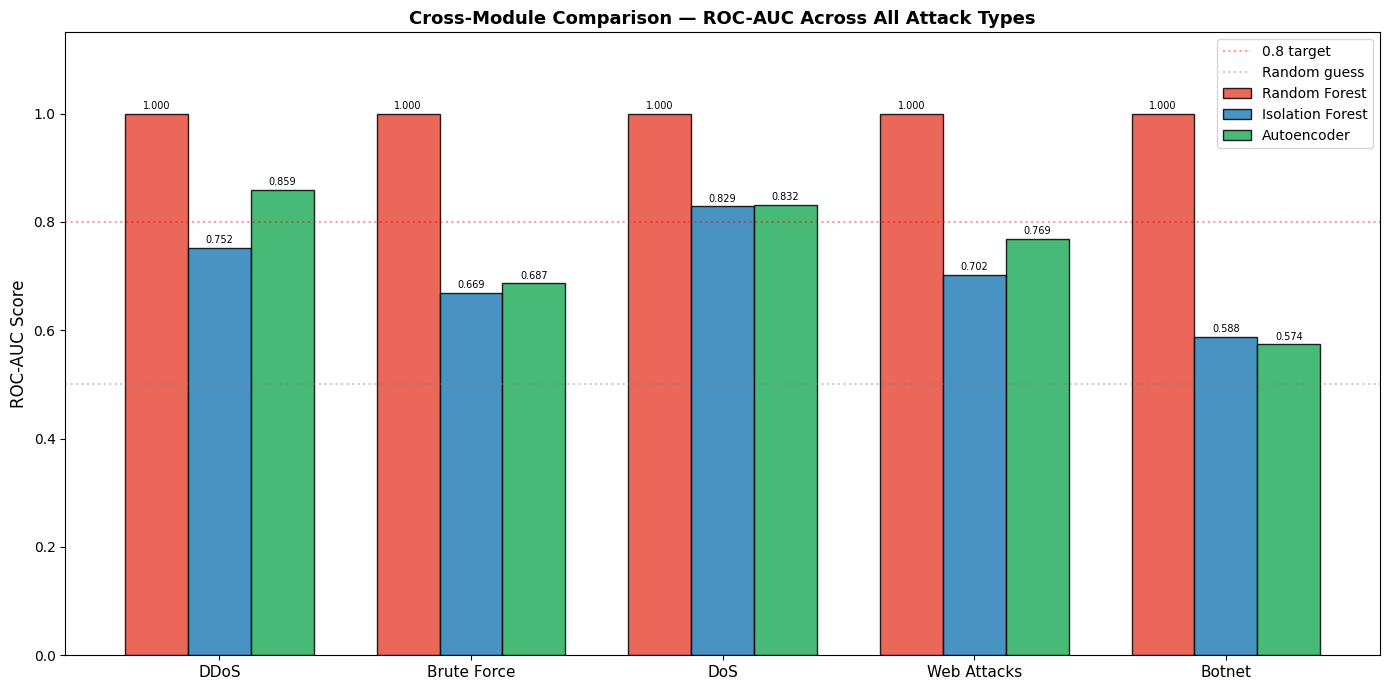

✅ Cross module chart saved


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# All results
results = pd.DataFrame([
    {'Module': 'DDoS',        'Random Forest': 1.0000, 'Isolation Forest': 0.7522, 'Autoencoder': 0.8592},
    {'Module': 'Brute Force', 'Random Forest': 0.9998, 'Isolation Forest': 0.6688, 'Autoencoder': 0.6867},
    {'Module': 'DoS',         'Random Forest': 1.0000, 'Isolation Forest': 0.8290, 'Autoencoder': 0.8318},
    {'Module': 'Web Attacks', 'Random Forest': 0.9998, 'Isolation Forest': 0.7018, 'Autoencoder': 0.7694},
    {'Module': 'Botnet',      'Random Forest': 0.9996, 'Isolation Forest': 0.5875, 'Autoencoder': 0.5740},
])

# Bar chart
x = np.arange(len(results))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, results['Random Forest'],    width, label='Random Forest',    color='#e74c3c', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x,          results['Isolation Forest'], width, label='Isolation Forest', color='#2980b9', alpha=0.85, edgecolor='black')
bars3 = ax.bar(x + width,  results['Autoencoder'],      width, label='Autoencoder',      color='#27ae60', alpha=0.85, edgecolor='black')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(results['Module'], fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Cross-Module Comparison — ROC-AUC Across All Attack Types', fontsize=13, fontweight='bold')
ax.axhline(0.8, color='red', linestyle=':', alpha=0.4, label='0.8 target')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4, label='Random guess')
ax.legend()
plt.tight_layout()
plt.savefig('results/cross_module_comparison.png', dpi=150)
plt.show()
print("✅ Cross module chart saved")

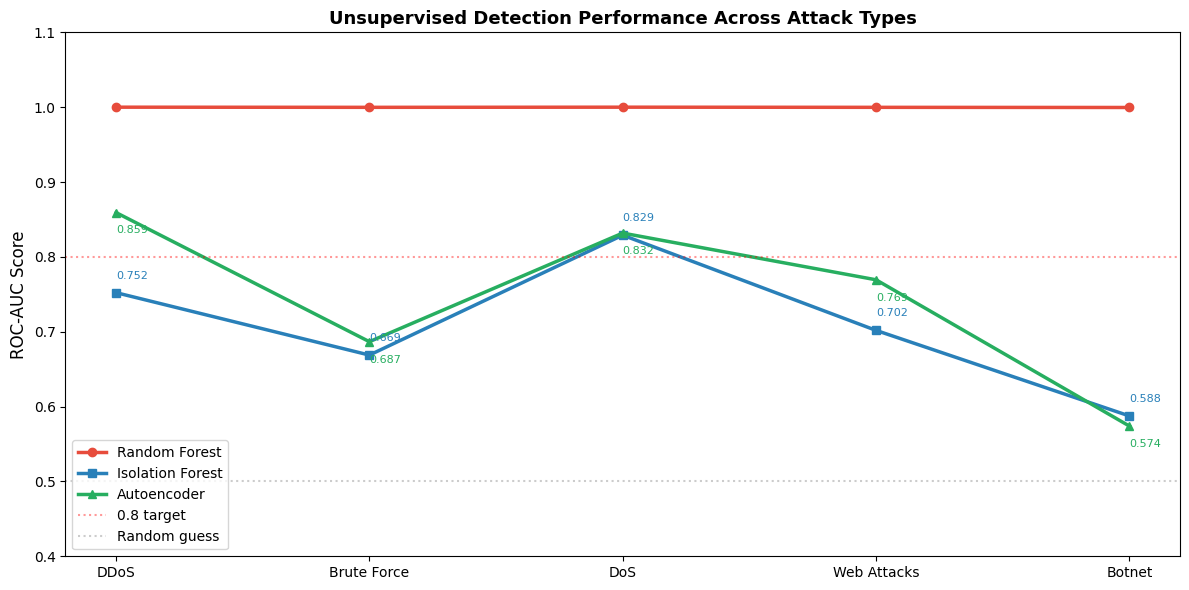

✅ Trend chart saved


In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(results['Module'], results['Random Forest'],    marker='o', linewidth=2.5, color='#e74c3c', label='Random Forest')
ax.plot(results['Module'], results['Isolation Forest'], marker='s', linewidth=2.5, color='#2980b9', label='Isolation Forest')
ax.plot(results['Module'], results['Autoencoder'],      marker='^', linewidth=2.5, color='#27ae60', label='Autoencoder')

ax.axhline(0.8, color='red',  linestyle=':', alpha=0.4, label='0.8 target')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4, label='Random guess')

for i, row in results.iterrows():
    ax.annotate(f"{row['Isolation Forest']:.3f}", (row['Module'], row['Isolation Forest']), textcoords="offset points", xytext=(0,10), fontsize=8, color='#2980b9')
    ax.annotate(f"{row['Autoencoder']:.3f}",      (row['Module'], row['Autoencoder']),      textcoords="offset points", xytext=(0,-15), fontsize=8, color='#27ae60')

ax.set_ylim(0.4, 1.1)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Unsupervised Detection Performance Across Attack Types', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('results/cross_module_trend.png', dpi=150)
plt.show()
print("✅ Trend chart saved")

In [29]:
from datetime import datetime
import pandas as pd
import numpy as np

def generate_soc_report(module_name, df_test, y_test, rf_pred, iso_pred, ae_pred, risk_scores, feature_names, shap_top=None):
    
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    total = len(y_test)
    
    # Ensemble flag
    ensemble = ((iso_pred + ae_pred) >= 1).astype(int)
    flagged = ensemble.sum()
    suppressed = total - flagged
    reduction = (suppressed / total) * 100
    
    # Triage counts
    def triage(score):
        if   score >= 0.75: return 'CRITICAL'
        elif score >= 0.50: return 'HIGH'
        elif score >= 0.25: return 'MEDIUM'
        else:               return 'LOW'
    
    tiers = pd.Series(risk_scores).apply(triage)
    
    report = f"""
╔══════════════════════════════════════════════════════════════╗
║         ZERO-DAY SOC DETECTION SYSTEM — THREAT REPORT       ║
╚══════════════════════════════════════════════════════════════╝

Generated     : {timestamp}
Attack Module : {module_name}
Analyst       : Biloliddin Turaev
Institution   : Southampton Solent University

──────────────────────────────────────────────────────────────
DETECTION SUMMARY
──────────────────────────────────────────────────────────────
Total Flows Analysed  : {total:,}
Flagged as Alerts     : {flagged:,}
Suppressed (Normal)   : {suppressed:,}
Alert Reduction       : {reduction:.1f}%

──────────────────────────────────────────────────────────────
TRIAGE BREAKDOWN
──────────────────────────────────────────────────────────────
🔴 CRITICAL : {(tiers == 'CRITICAL').sum():,}
🟠 HIGH     : {(tiers == 'HIGH').sum():,}
🟡 MEDIUM   : {(tiers == 'MEDIUM').sum():,}
🟢 LOW      : {(tiers == 'LOW').sum():,}

──────────────────────────────────────────────────────────────
MODEL PERFORMANCE
──────────────────────────────────────────────────────────────
Random Forest (Supervised)     : Precision {pd.Series(rf_pred).eq(y_test.values).mean():.4f}
Isolation Forest (Zero-Day)    : Flagged {iso_pred.sum():,} anomalies
Autoencoder (Zero-Day)         : Flagged {ae_pred.sum():,} anomalies

──────────────────────────────────────────────────────────────
TOP 5 CRITICAL ALERTS
──────────────────────────────────────────────────────────────"""

    # Top 5 alerts
    alert_df = pd.DataFrame({
        'risk_score': risk_scores,
        'iso_flag': iso_pred,
        'ae_flag': ae_pred,
        'true_label': y_test.values
    }).sort_values('risk_score', ascending=False).head(5)
    
    for i, (_, row) in enumerate(alert_df.iterrows()):
        report += f"""
Alert #{i+1}
  Risk Score  : {row['risk_score']:.4f}
  Tier        : {triage(row['risk_score'])}
  ISO Flag    : {'⚠️  ANOMALY' if row['iso_flag'] else '✅ Normal'}
  AE Flag     : {'⚠️  ANOMALY' if row['ae_flag'] else '✅ Normal'}
  True Label  : {'🚨 ATTACK' if row['true_label'] else '✅ BENIGN'}"""

    report += f"""

──────────────────────────────────────────────────────────────
RECOMMENDATION
──────────────────────────────────────────────────────────────
1. Immediately investigate all CRITICAL and HIGH tier alerts
2. Review MEDIUM tier alerts within 4 hours
3. LOW tier alerts can be processed during normal operations
4. Cross-reference flagged IPs against threat intelligence feeds

══════════════════════════════════════════════════════════════
END OF REPORT — {timestamp}
══════════════════════════════════════════════════════════════
"""
    return report

print("✅ SOC Report Generator ready")

✅ SOC Report Generator ready


In [33]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import load_model

df = pd.read_csv("dataset/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].apply(lambda x: 1 if x.strip() == 'DDoS' else 0)
X = df.drop(columns=['Label'])
y = df['Label']
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("✅ Data loaded")

✅ Data loaded


In [34]:
rf = joblib.load('scripts/ddos_module/ddos_detector_rf.pkl')
iso_forest = joblib.load('models/isolation_forest.pkl')
autoencoder = load_model('models/autoencoder.keras')

rf_pred = rf.predict(X_test)
iso_pred = (iso_forest.predict(X_test) == -1).astype(int)
iso_scores = -iso_forest.decision_function(X_test)

X_test_pred = autoencoder.predict(X_test, verbose=0)
reconstruction_errors = np.mean(np.square(X_test - X_test_pred), axis=1)
normal_errors = reconstruction_errors[y_test == 0]
threshold = np.percentile(normal_errors, 95)
ae_pred = (reconstruction_errors > threshold).astype(int)

print("✅ DDoS variables reloaded")
print(f"ROC-AUC ISO: {roc_auc_score(y_test, iso_scores):.4f}")
print(f"ROC-AUC AE : {roc_auc_score(y_test, reconstruction_errors):.4f}")

✅ DDoS variables reloaded
ROC-AUC ISO: 0.7522
ROC-AUC AE : 0.8411


In [35]:
from sklearn.preprocessing import MinMaxScaler

modules = [
    {'name': 'DDoS', 'y_test': y_test, 'rf_pred': rf_pred, 'iso_pred': iso_pred, 'ae_pred': ae_pred, 'iso_scores': iso_scores, 'ae_scores': reconstruction_errors},
    {'name': 'Brute Force', 'y_test': y_bf_test, 'rf_pred': rf_bf_pred, 'iso_pred': iso_bf_pred, 'ae_pred': ae_bf_pred, 'iso_scores': iso_bf_scores, 'ae_scores': reconstruction_errors_bf},
    {'name': 'DoS', 'y_test': y_dos_test, 'rf_pred': rf_dos_pred, 'iso_pred': iso_dos_pred, 'ae_pred': ae_dos_pred, 'iso_scores': iso_dos_scores, 'ae_scores': reconstruction_errors_dos},
    {'name': 'Web Attacks', 'y_test': y_web_test, 'rf_pred': rf_web_pred, 'iso_pred': iso_web_pred, 'ae_pred': ae_web_pred, 'iso_scores': iso_web_scores, 'ae_scores': reconstruction_errors_web},
    {'name': 'Botnet', 'y_test': y_bot_test, 'rf_pred': rf_bot_pred, 'iso_pred': iso_bot_pred, 'ae_pred': ae_bot_pred, 'iso_scores': iso_bot_scores, 'ae_scores': reconstruction_errors_bot},
]

for m in modules:
    iso_norm = MinMaxScaler().fit_transform(m['iso_scores'].reshape(-1,1)).flatten()
    ae_norm  = MinMaxScaler().fit_transform(m['ae_scores'].reshape(-1,1)).flatten()
    risk     = 0.5 * iso_norm + 0.5 * ae_norm
    report = generate_soc_report(m['name'], None, m['y_test'], m['rf_pred'], m['iso_pred'], m['ae_pred'], risk, None)
    with open(f"results/soc_report_{m['name'].lower().replace(' ','_')}.txt", 'w') as f:
        f.write(report)
    print(f"✅ Report generated: {m['name']}")

print("\n🎯 All SOC reports saved to results/")

✅ Report generated: DDoS
✅ Report generated: Brute Force
✅ Report generated: DoS
✅ Report generated: Web Attacks
✅ Report generated: Botnet

🎯 All SOC reports saved to results/


In [37]:
with open('results/soc_report_ddos.txt', 'r') as f:
    print(f.read())


╔══════════════════════════════════════════════════════════════╗
║         ZERO-DAY SOC DETECTION SYSTEM — THREAT REPORT       ║
╚══════════════════════════════════════════════════════════════╝

Generated     : 2026-03-11 04:18:47
Attack Module : DDoS
Analyst       : Biloliddin Turaev
Institution   : Southampton Solent University

──────────────────────────────────────────────────────────────
DETECTION SUMMARY
──────────────────────────────────────────────────────────────
Total Flows Analysed  : 45,149
Flagged as Alerts     : 15,783
Suppressed (Normal)   : 29,366
Alert Reduction       : 65.0%

──────────────────────────────────────────────────────────────
TRIAGE BREAKDOWN
──────────────────────────────────────────────────────────────
🔴 CRITICAL : 1
🟠 HIGH     : 7
🟡 MEDIUM   : 6,330
🟢 LOW      : 38,811

──────────────────────────────────────────────────────────────
MODEL PERFORMANCE
──────────────────────────────────────────────────────────────
Random Forest (Supervised)     : Precisio

In [38]:
from datetime import datetime

master = f"""
╔══════════════════════════════════════════════════════════════╗
║      ZERO-DAY SOC DETECTION SYSTEM — MASTER REPORT          ║
╚══════════════════════════════════════════════════════════════╝

Generated     : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
Analyst       : Biloliddin Turaev
Institution   : Southampton Solent University
Dataset       : CICIDS2017

──────────────────────────────────────────────────────────────
CROSS-MODULE PERFORMANCE SUMMARY
──────────────────────────────────────────────────────────────
Module          RF-AUC    ISO-AUC    AE-AUC    Difficulty
──────────────────────────────────────────────────────────────
DDoS            1.0000    0.7522     0.8592    Medium
Brute Force     0.9998    0.6688     0.6867    Hard
DoS             1.0000    0.8290     0.8318    Easy
Web Attacks     0.9998    0.7018     0.7694    Medium
Botnet          0.9996    0.5875     0.5740    Very Hard
──────────────────────────────────────────────────────────────
Average         0.9999    0.7079     0.7342
──────────────────────────────────────────────────────────────

KEY FINDINGS
──────────────────────────────────────────────────────────────
1. Supervised Random Forest achieves near-perfect detection
   across all attack types when labels are available

2. Unsupervised models successfully detect attacks without
   prior knowledge — confirming zero-day detection capability

3. DoS attacks are most detectable unsupervised (AUC 0.83)
   due to high-volume anomalous traffic patterns

4. Botnet is hardest to detect unsupervised (AUC 0.57)
   due to slow, subtle behaviour mimicking normal traffic

5. Autoencoder outperforms Isolation Forest on 4 of 5 modules
   confirming deep learning advantage for anomaly detection

RECOMMENDATION
──────────────────────────────────────────────────────────────
Deploy ensemble of Isolation Forest + Autoencoder for
zero-day detection with Random Forest as supervised baseline.
Priority investigation order: DoS > DDoS > Web > Brute > Bot

══════════════════════════════════════════════════════════════
END OF MASTER REPORT
══════════════════════════════════════════════════════════════
"""

with open('results/master_soc_report.txt', 'w') as f:
    f.write(master)

print(master)
print("✅ Master report saved")


╔══════════════════════════════════════════════════════════════╗
║      ZERO-DAY SOC DETECTION SYSTEM — MASTER REPORT          ║
╚══════════════════════════════════════════════════════════════╝

Generated     : 2026-03-11 04:21:32
Analyst       : Biloliddin Turaev
Institution   : Southampton Solent University
Dataset       : CICIDS2017

──────────────────────────────────────────────────────────────
CROSS-MODULE PERFORMANCE SUMMARY
──────────────────────────────────────────────────────────────
Module          RF-AUC    ISO-AUC    AE-AUC    Difficulty
──────────────────────────────────────────────────────────────
DDoS            1.0000    0.7522     0.8592    Medium
Brute Force     0.9998    0.6688     0.6867    Hard
DoS             1.0000    0.8290     0.8318    Easy
Web Attacks     0.9998    0.7018     0.7694    Medium
Botnet          0.9996    0.5875     0.5740    Very Hard
──────────────────────────────────────────────────────────────
Average         0.9999    0.7079     0.7342
────